# Reranqueamento Pedagógico Two-Stage sobre Base Estruturada de OAs
## v_FINAL BRACIS — com validações humanas, estatística expandida e grid search opcional

Este notebook é a **versão final para submissão BRACIS**. Herda o pipeline v10 validado e acrescenta tudo que foi possível endereçar com base nos dados anotados por juízes humanos + melhorias metodológicas identificadas em peer review:

### Novidades sobre v10
- **NDCG_ped_nolas** — NDCG pedagógico desacoplado do termo LAS (evita circularidade com o sinal otimizado pelo S5).
- **Estatística expandida** — bootstrap pareado sobre diferenças, Wilcoxon com correção de Holm–Bonferroni entre S5 e baselines, *r* de Wilcoxon e Cliff's delta como tamanhos de efeito.
- **Grid search dos pesos do reranker** — opcional (célula com toggle), k-fold estratificado por bins de nível sobre 17 queries train × 8 held-out.
- **Análise de sensibilidade do nível ontológico inferido** — 4 estratégias de agregação × 3 limiares de dispersão conservador.
- **Bloco H — Validações humanas**:
  - **H1**: Kappa de Cohen (simples, linear, quadrático) entre dois juízes independentes sobre 210 pares query–OA.
  - **H2**: Validação do nível ontológico inferido por especialista em amostra de 98 OAs (Spearman ρ, MAE, % |dif|≤1).
  - **H3**: Gold humano construído a partir do pool anotado; re-avaliação dos sistemas sobre pares humanamente rotulados.
  - **H4**: 20 consultas reais coletadas de gestores em exercício, executadas sobre o corpus real como **Bloco D** paralelo às sintéticas.

### Arquivos que você precisa subir no Colab
- `base_odas.csv` — corpus original de 9.349 OAs (já utilizado no v1)
- `pool_query_oa_juiz1_preenchido.csv`
- `pool_query_oa_juiz2_preenchido.csv`
- `nivel_ontologico_especialista_preenchido.csv`
- `consultas_reais_preenchido.csv`

Se algum dos arquivos humanos não estiver disponível, as seções correspondentes do Bloco H serão puladas com aviso explícito — o pipeline principal roda mesmo assim.

### Estrutura do notebook
1. **Parte 1 — Pipeline v1 validado** (§1 a §17): inalterado, preservando resultados do paper já escrito.
2. **Parte 2 — Análise estendida v10** (§18 a §22): bootstrap, NDCG desacoplado, BM25 vs Dense, análise qualitativa — inalterada.
3. **Parte 3 — Novidades BRACIS** (§24 a §32, abaixo): tudo que responde ao peer review e aos dados humanos.
4. **Relatório consolidado** no final.


In [ ]:
# ============================================================
# REPRODUTIBILIDADE GLOBAL
# Rodar esta célula ANTES de qualquer modelo, embedding ou métrica
# ============================================================

import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    # Tenta forçar determinismo no PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Mais rigoroso; se alguma operação não for determinística, pode dar erro
    torch.use_deterministic_algorithms(True, warn_only=True)

    print("PyTorch determinístico configurado.")
except ImportError:
    print("PyTorch não importado ainda.")

print(f"Seed global fixada em {SEED}")

PyTorch determinístico configurado.
Seed global fixada em 42


## 1. Setup

In [ ]:
!pip install -q sentence-transformers==3.0.1 FlagEmbedding==1.2.11 \
    rank_bm25==0.2.2 networkx==3.3 pandas==2.2.2 pyarrow==16.1.0 \
    scikit-learn==1.5.0 matplotlib==3.9.0 ipywidgets==8.1.3

In [ ]:
import os, re, json, time, unicodedata, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Set
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

OUT = Path('./resultados_v8')
OUT.mkdir(exist_ok=True)
for s in ['rankings','metricas','corpus','perfis','figuras']:
    (OUT / s).mkdir(exist_ok=True)

USE_LIGHT_RERANKER = True  # True = mais rápido; False = v2-m3 (mais pesado)
print(f'Saída: {OUT.resolve()}')
print(f'Cross-encoder: {"leve (base)" if USE_LIGHT_RERANKER else "SOTA (v2-m3)"}')

Saída: /content/resultados_v8
Cross-encoder: leve (base)


## 2. Carregamento da base `base_odas.csv`

A base traz OAs reais da plataforma no formato:

- `Título`
- `URL`  
- `Número caracteres`
- `Resumo completo` — contém metadados estruturados em texto (Tipo, Suporte, Duração, Temas, Dimensões, Palavras-chave, Termos controlados) mais uma descrição narrativa.

O parser abaixo extrai os campos estruturados via expressões regulares. Linhas com resumo muito curto (< 80 chars) ou sem título são descartadas.

In [ ]:
# No Colab, descomente se quiser subir manualmente:
# from google.colab import files
# uploaded = files.upload()
# BASE_PATH = list(uploaded.keys())[0]

BASE_PATH = 'base_odas.csv'  # ajuste se necessário

def read_base(path):
    for enc in ('utf-8-sig', 'utf-8', 'latin1'):
        try:
            return pd.read_csv(path, sep=';', encoding=enc, engine='python', on_bad_lines='skip')
        except Exception:
            continue
    raise RuntimeError(f'Falha ao ler {path}')

base_df = read_base(BASE_PATH)

rename = {}
for c in base_df.columns:
    cl = c.lower().strip()
    if 'título' in cl or 'titulo' in cl:
        rename[c] = 'titulo'
    elif cl == 'url' or 'link' in cl:
        rename[c] = 'url'
    elif 'número caracteres' in cl or 'numero caracteres' in cl:
        rename[c] = 'n_chars'
    elif 'resumo completo' in cl:
        rename[c] = 'resumo_completo'
    elif 'resumo' == cl:
        rename[c] = 'resumo_completo'

base_df = base_df.rename(columns=rename)

needed = ['titulo', 'url', 'resumo_completo']
missing = [c for c in needed if c not in base_df.columns]
if missing:
    raise ValueError(f'Colunas ausentes: {missing}')

base_df = base_df.dropna(subset=['titulo','resumo_completo']).copy()
base_df['titulo'] = base_df['titulo'].astype(str).str.strip()
base_df['url'] = base_df.get('url', pd.Series(['']*len(base_df))).fillna('').astype(str).str.strip()
base_df['resumo_completo'] = base_df['resumo_completo'].astype(str).str.strip()
if 'n_chars' not in base_df.columns:
    base_df['n_chars'] = base_df['resumo_completo'].str.len()

base_df = base_df.drop_duplicates(subset=['titulo','url']).reset_index(drop=True)
print(f'Base carregada: {len(base_df)} linhas')
base_df.head(2)

Base carregada: 9357 linhas


,titulo,url,n_chars,resumo_completo
0,Currículo Estadual de São Paulo – Etapa Ensino...,https://efape.educacao.sp.gov.br/curriculopaul...,53600,Currículo Estadual de São Paulo – Etapa Ensino...
1,Currículo do Espírito Santo – Texto introdutór...,https://drive.google.com/file/d/1B41xYpgWgvZGd...,55200,Currículo do Espírito Santo – Texto introdutór...


In [ ]:
import re
import pandas as pd

def parse_structured_summary(text):
    # Garante string válida
    t = '' if pd.isna(text) else str(text)
    t = re.sub(r'\s+', ' ', t).strip()

    labels = [
        'Tipo',
        'Suporte',
        'Duração/Tamanho',
        'Temas',
        'Dimensões',
        'Palavras-chave',
        'Termos controlados'
    ]

    def get_field(label):
        # Captura até o próximo rótulo conhecido ou fim do texto
        next_labels = '|'.join(re.escape(l) for l in labels if l != label)
        pat = rf'{re.escape(label)}:\s*(.*?)(?=\s*(?:{next_labels}):|$)'
        m = re.search(pat, t, flags=re.I)
        if not m:
            return ''
        value = m.group(1)
        return value.strip(' .;') if value else ''

    def split_multi(s):
        if not s:
            return []
        parts = re.split(r'\s*\|\s*|\s*,\s*|\s*;\s*', s)
        return [p.strip() for p in parts if p.strip()]

    campos = {
        'tipo': get_field('Tipo'),
        'suporte': get_field('Suporte'),
        'duracao_tamanho': get_field('Duração/Tamanho'),
        'temas': split_multi(get_field('Temas')),
        'dimensoes': split_multi(get_field('Dimensões')),
        'palavras_chave': split_multi(get_field('Palavras-chave')),
        'termos_controlados': split_multi(get_field('Termos controlados')),
    }

    # Texto residual como descrição livre
    desc = t
    for label in labels:
        value = get_field(label)
        if value:
            desc = re.sub(
                rf'{re.escape(label)}:\s*{re.escape(value)}',
                '',
                desc,
                flags=re.I
            )

    desc = re.sub(r'\s+', ' ', desc).strip(' .;')
    campos['descricao_livre'] = desc

    return campos

parsed = base_df['resumo_completo'].apply(parse_structured_summary)
parsed_df = pd.DataFrame(parsed.tolist())
base_df = pd.concat([base_df, parsed_df], axis=1)

print("Campos extraídos com sucesso.")
display(
    base_df[
        [
            'titulo',
            'tipo',
            'suporte',
            'duracao_tamanho',
            'temas',
            'dimensoes',
            'palavras_chave',
            'termos_controlados'
        ]
    ].head(3)
)

Campos extraídos com sucesso.


,titulo,tipo,suporte,duracao_tamanho,temas,dimensoes,palavras_chave,termos_controlados
0,Currículo Estadual de São Paulo – Etapa Ensino...,"Manuais, materiais e textos de orientação e apoio",Texto,301 páginas,"[Clima e ambiente escolar, Avaliação, Formação...","[Gestão Escolar, Gestão de Ensino e Aprendizagem]","[Formação continuada docente, Formação inicial...","[Clima e ambiente escolar, Avaliação, Formação..."
1,Currículo do Espírito Santo – Texto introdutór...,"Manuais, materiais e textos de orientação e apoio",Texto,38 páginas,"[Currículo, Formação, Modalidades e níveis de ...","[Gestão de Ensino e Aprendizagem, Gestão Educa...","[Protagonismo juvenil, Reforma curricular, Ens...","[Currículo, Formação, Modalidades e níveis de ..."
2,Currículo do Espírito Santo – Linguagens e sua...,"Manuais, materiais e textos de orientação e apoio",Texto,107 páginas,[],"[Gestão Educacional, Gestão de Ensino e Aprend...","[Linguagens, Tecnologia, Reforma curricular, E...","[Linguagens, Tecnologia, Reforma curricular, E..."


## 3. Rubrica diagnóstica — 7 devolutivas da especialista

Para cada um dos 7 níveis de proficiência em planejamento pedagógico, a especialista humana escreveu duas devolutivas:

- `ja_sabe`: o que o gestor naquele nível já domina
- `para_avancar`: o que ele precisa desenvolver para subir de nível

Esses textos são o **insumo supervisionado** que dá à camada pedagógica um sinal humano real para cada perfil de gestor.

In [ ]:
DEVOLUTIVAS = {
    1: {'ja_sabe': 'Você já reconhece a importância do planejamento pedagógico e demonstra compromisso em viabilizar momentos e espaços para que ele aconteça. Está no caminho certo para desenvolver práticas fundamentais na gestão do planejamento escolar.',
        'para_avancar': 'Antes de avançar, é necessário consolidar este nível. Para isso, será essencial compreender mais profundamente o planejamento pedagógico, assegurar condições básicas para que os professores realizem seu planejamento e organizar rotinas e um calendário ao longo do ano. Também será importante conhecer os fundamentos básicos da recomposição de aprendizagens.'},
    2: {'ja_sabe': 'Você já reconhece a importância do planejamento pedagógico e se sente preparado(a) para viabilizar momentos e espaços para sua realização. Você se percebe preparado(a) para assegurar que os professores elaborem e implementem suas propostas, evidenciando compromisso com o processo de planejamento pedagógico na escola.',
        'para_avancar': 'Será necessário assumir um papel mais ativo de mediação, promovendo um planejamento mais integrado e colaborativo, conectado a diagnósticos e objetivos institucionais, incluindo a recomposição de aprendizagens.'},
    3: {'ja_sabe': 'Você já se sente preparado(a) para assumir um papel ativo na mediação do planejamento pedagógico e para começar a alinhar esse processo às diretrizes institucionais e políticas educacionais.',
        'para_avancar': 'Será necessário fortalecer o uso consistente de dados de aprendizagem dos estudantes como base do planejamento, inclusive para recomposição das aprendizagens, e consolidar a mediação de discussões pedagógicas com os professores.'},
    4: {'ja_sabe': 'Você já se sente preparado(a) para desempenhar um papel ativo na mediação do planejamento pedagógico, garantindo que ele seja baseado em um diagnóstico de aprendizagem dos estudantes. Você se percebe preparado(a) para promover discussões importantes sobre o alinhamento do planejamento com as políticas educacionais e a proposta pedagógica da escola, além de monitorar se as ações estão sendo implementadas conforme planejado.',
        'para_avancar': 'Será fundamental ampliar o escopo do diagnóstico, estruturar melhor o monitoramento e replanejamento e fornecer apoio consistente aos professores, com diretrizes claras e devolutivas construtivas.'},
    5: {'ja_sabe': 'Você já se sente preparado(a) para liderar o processo de planejamento pedagógico de forma consistente e estruturada, buscando o alinhamento entre o diagnóstico, a proposta da escola e as diretrizes externas.',
        'para_avancar': 'Será necessário fortalecer o diagnóstico das práticas pedagógicas dos professores, usá-lo para orientar objetivos e estratégias (incluindo recomposição), qualificar devolutivas e garantir acompanhamento sistemático dos resultados.'},
    6: {'ja_sabe': 'Você já se sente preparado(a) para liderar o planejamento pedagógico de forma consistente e estruturada, conectando o diagnóstico da aprendizagem e do ensino a objetivos e estratégias claras. Você se percebe preparado para assegurar o alinhamento com o PPP, a BNCC e outras políticas educacionais. Além disso, você se avalia capacitado(a) para instituir calendários e rotinas bem definidas para a elaboração, desdobramento e revisão do planejamento, fornecendo suporte técnico e devolutivas construtivas à equipe.',
        'para_avancar': 'Será necessário promover maior autonomia da equipe e consolidar interdisciplinaridade e inovação como práticas sustentáveis, incorporando a recomposição das aprendizagens à cultura da escola.'},
    7: {'ja_sabe': 'Você já se sente preparado(a) para promover uma cultura escolar em que o planejamento pedagógico seja consistente, colaborativo, contínuo e sustentável. Você se percebe preparado para integrar os objetivos e estratégias pedagógicas com o diagnóstico da escola e as políticas educacionais, fortalecendo a interdisciplinaridade e a inovação. Além disso, você se avalia capacitado(a) para envolver professores, estudantes, famílias e demais atores escolares, criando um ambiente de engajamento e autonomia coletiva.',
        'para_avancar': 'É importante garantir que as práticas sustentáveis continuem evoluindo, mantendo a cultura adaptável, fortalecendo a distribuição de liderança e consolidando a recomposição das aprendizagens como parte da cultura escolar.'},
}
NIVEIS = sorted(DEVOLUTIVAS.keys())
json.dump(DEVOLUTIVAS, open(OUT/'perfis'/'devolutivas.json','w'), indent=2, ensure_ascii=False)
print(f'{len(DEVOLUTIVAS)} níveis de proficiência')

7 níveis de proficiência


## 4. Configuração

Pesos do reranker pedagógico são **manuais e transparentes** nesta versão (grid search fica para trabalho futuro; justificativa empírica abaixo).

A distribuição de pesos reflete dois princípios:

- **Cross-encoder domina** (`cross=0.56`) — é o sinal semântico mais confiável.
- **Ontologia é o principal sinal pedagógico** (`prereq=0.12` + `las=0.10` = 0.22) — confirmado empiricamente na v5 e v7.
- Perfil estruturado, dimensão e formato recebem pesos pequenos (0.03–0.10) — a ablação (tabela D) confirma que são contribuições marginais.

In [ ]:
CONFIG = {
    'nome_experimento': 'rag_gestao_escolar_v9_ajustada',
    'arquivo_base': BASE_PATH,
    'embedding_model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'cross_encoder': 'BAAI/bge-reranker-base' if USE_LIGHT_RERANKER else 'BAAI/bge-reranker-v2-m3',

    # escopo do corpus
    'dimensoes_alvo': ['Gestão Escolar', 'Gestão de Ensino e Aprendizagem'],
    'areas_mec_prioritarias': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6'],

    # tamanhos das stages
    'top_k_retrieval': 80,
    'top_k_rerank': 20,
    'top_k_final': 10,
    'final_top_k': 10,

    # aliases usados por células herdadas
    'bm25_top_k': 80,
    'dense_top_k': 80,
    'hybrid_top_k': 80,
    'cross_top_k': 20,
    'retrieval_top_k': 80,
    'rerank_top_k': 20,
    'rrf_k': 60,

    # matching de conceitos (mais restritivo)
    'conceito_top_n': 4,
    'conceito_threshold': 0.44,
    'fallback_semantico_max': 1,

    # avaliação
    'ndcg_k': [5, 10],
    'mrr_k': 10,

    # opções metodológicas da V9 ajustada
    'usar_perfil_textual_especialista': False,
    'usar_formato_tamanho': True,
    'conceito_match_modo': 'restritivo',

    # pesos pedagógicos finais
    'peso_dense': 0.35,
    'peso_sparse': 0.15,
    'peso_conceitos': 0.22,
    'peso_prereq': 0.12,
    'peso_las': 0.11,
    'peso_area_mec': 0.08,
    'peso_dimensao': 0.05,
    'peso_formato': 0.05,
}

CONFIG['ped_weights'] = {
    'cross': 0.56,
    'perfil_estruturado': 0.10,
    'prerequisitos': 0.12,
    'las': 0.10,
    'area_mec': 0.06,
    'dimensao': 0.03,
    'formato': 0.03,
}

def to_jsonable(obj):
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, set):
        return sorted(list(obj))
    return obj

with open(OUT / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(to_jsonable(CONFIG), f, indent=2, ensure_ascii=False)

print('Configuração salva em:', OUT / 'config.json')
for k, v in CONFIG.items():
    if k != 'ped_weights':
        print(f'  {k}: {v}')
print('  ped_weights:', CONFIG['ped_weights'])

Configuração salva em: resultados_v8/config.json
  nome_experimento: rag_gestao_escolar_v9_ajustada
  arquivo_base: base_odas.csv
  embedding_model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  cross_encoder: BAAI/bge-reranker-base
  dimensoes_alvo: ['Gestão Escolar', 'Gestão de Ensino e Aprendizagem']
  areas_mec_prioritarias: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
  top_k_retrieval: 80
  top_k_rerank: 20
  top_k_final: 10
  final_top_k: 10
  bm25_top_k: 80
  dense_top_k: 80
  hybrid_top_k: 80
  cross_top_k: 20
  retrieval_top_k: 80
  rerank_top_k: 20
  rrf_k: 60
  conceito_top_n: 4
  conceito_threshold: 0.44
  fallback_semantico_max: 1
  ndcg_k: [5, 10]
  mrr_k: 10
  usar_perfil_textual_especialista: False
  usar_formato_tamanho: True
  conceito_match_modo: restritivo
  peso_dense: 0.35
  peso_sparse: 0.15
  peso_conceitos: 0.22
  peso_prereq: 0.12
  peso_las: 0.11
  peso_area_mec: 0.08
  peso_dimensao: 0.05
  peso_formato: 0.05
  ped_weights: {'cross': 0.56, 'perfil_e

## 5. Ontologia — duas camadas (Tier 1 regulatório + Tier 2 do especialista)

25 conceitos organizados em **duas camadas**, seguindo o enquadramento do artigo:

**Tier 1 — Dimensões (ancoragem regulatória).** As 4 dimensões da Matriz do Diretor Escolar (Político-Institucional, **Pedagógica**, Administrativo-Financeira, Pessoal-Relacional) vêm diretamente do Parecer CNE/CP nº 4/2021. Nosso foco é a Pedagógica, usada como **pré-filtro do corpus**. Esta é a única camada verificável contra o documento oficial.

**Tier 2 — Agrupamentos e conceitos (contribuição analítica do especialista).** Sobre o Tier 1, o especialista introduz:
1. **Seis agrupamentos temáticos** da dimensão Pedagógica — referidos como **G1–G6** no artigo (rotulados `A1`–`A6` / `area_mec` no código deste notebook). Usados para o sinal de alinhamento de área.
2. **25 conceitos operacionais** extraídos da rubrica, com atributos: `nivel` (1–7), `area_mec` (A1–A6 ≡ G1–G6), `prereq` (lista), `aliases` (formas lexicais), `anchors` (termos-gatilho canônicos).

> **Escopo da ancoragem (importante).** Apenas o **Tier 1** tem status regulatório. Os agrupamentos G1–G6, os 25 conceitos e a rubrica de 7 níveis são a contribuição analítica do especialista e **não têm status regulatório**; em particular, **G1–G6 não correspondem** às cinco competências específicas (B.1–B.5) que a Matriz define na dimensão Pedagógica. A defesa contra a crítica de "ontologia ad hoc" se apoia em duas evidências de pesos distintos: proveniência regulatória para o Tier 1, e validação empírica (concordância entre juízes, anotação de nível por especialista, robustez à agregação, réplica em consultas reais) para o Tier 2.

In [ ]:
ONTOLOGIA = {
    'planejamento pedagógico': {
        'nivel': 1, 'area_mec': 'A2', 'prereq': [],
        'aliases': ['planejamento pedagógico', 'planejamento escolar', 'planejamento de ensino'],
        'anchors': ['planejamento pedagógico', 'planejamento escolar']
    },
    'rotinas e calendário escolar': {
        'nivel': 1, 'area_mec': 'A2', 'prereq': ['planejamento pedagógico'],
        'aliases': ['rotinas', 'calendário escolar', 'calendario escolar', 'planejamento anual'],
        'anchors': ['rotinas', 'calendário', 'planejamento anual']
    },
    'organização de tempos e espaços pedagógicos': {
        'nivel': 1, 'area_mec': 'A2', 'prereq': ['planejamento pedagógico'],
        'aliases': ['tempos e espaços', 'espaços pedagógicos', 'organizacao dos tempos', 'organização dos tempos'],
        'anchors': ['tempos e espaços', 'espaços pedagógicos']
    },
    'recomposição de aprendizagens': {
        'nivel': 1, 'area_mec': 'A1', 'prereq': ['planejamento pedagógico'],
        'aliases': ['recomposição de aprendizagens', 'recomposicao de aprendizagens'],
        'anchors': ['recomposição de aprendizagens']
    },
    'mediação pedagógica': {
        'nivel': 2, 'area_mec': 'A3', 'prereq': ['planejamento pedagógico'],
        'aliases': ['mediação pedagógica', 'mediacao pedagogica'],
        'anchors': ['mediação pedagógica']
    },
    'planejamento colaborativo': {
        'nivel': 2, 'area_mec': 'A2', 'prereq': ['mediação pedagógica'],
        'aliases': ['planejamento colaborativo', 'planejamento integrado', 'trabalho colaborativo'],
        'anchors': ['planejamento colaborativo']
    },
    'objetivos institucionais e metas': {
        'nivel': 2, 'area_mec': 'A1', 'prereq': ['planejamento pedagógico'],
        'aliases': ['objetivos institucionais', 'metas institucionais', 'metas da escola'],
        'anchors': ['objetivos institucionais', 'metas']
    },
    'avaliação diagnóstica': {
        'nivel': 2, 'area_mec': 'A4', 'prereq': ['planejamento pedagógico'],
        'aliases': ['avaliação diagnóstica', 'avaliacao diagnostica', 'diagnóstico inicial', 'diagnostico inicial'],
        'anchors': ['avaliação', 'diagnóstico', 'processo de aprendizagem']
    },
    'dados de aprendizagem e indicadores': {
        'nivel': 3, 'area_mec': 'A4', 'prereq': ['avaliação diagnóstica'],
        'aliases': ['dados de aprendizagem', 'indicadores', 'indicadores educacionais'],
        'anchors': ['avaliação', 'indicadores', 'dados de aprendizagem']
    },
    'discussões pedagógicas e formação continuada': {
        'nivel': 3, 'area_mec': 'A3', 'prereq': ['mediação pedagógica'],
        'aliases': ['discussões pedagógicas', 'htpc', 'formação continuada', 'formacao continuada'],
        'anchors': ['formação continuada docente', 'discussões pedagógicas', 'HTPC']
    },
    'diretrizes e políticas educacionais': {
        'nivel': 3, 'area_mec': 'A1', 'prereq': ['objetivos institucionais e metas'],
        'aliases': ['diretrizes institucionais', 'políticas educacionais', 'politicas educacionais'],
        'anchors': ['currículo', 'curriculo', 'diretrizes', 'políticas']
    },
    'bncc e currículo': {
        'nivel': 3, 'area_mec': 'A4', 'prereq': ['diretrizes e políticas educacionais'],
        'aliases': ['bncc', 'currículo', 'curriculo', 'bncc e currículo', 'bncc e curriculo'],
        'anchors': ['BNCC', 'currículo', 'curriculo']
    },
    'monitoramento do planejamento': {
        'nivel': 4, 'area_mec': 'A2', 'prereq': ['dados de aprendizagem e indicadores'],
        'aliases': ['monitoramento do planejamento', 'monitoramento pedagógico', 'monitoramento pedagogico'],
        'anchors': ['monitoramento']
    },
    'replanejamento pedagógico': {
        'nivel': 4, 'area_mec': 'A2', 'prereq': ['monitoramento do planejamento'],
        'aliases': ['replanejamento', 'replanejamento pedagógico', 'replanejamento pedagogico'],
        'anchors': ['replanejamento']
    },
    'devolutivas e feedback docente': {
        'nivel': 4, 'area_mec': 'A3', 'prereq': ['discussões pedagógicas e formação continuada'],
        'aliases': ['devolutivas construtivas', 'feedback docente', 'devolutivas aos professores'],
        'anchors': ['feedback', 'devolutiva']
    },
    'apoio e suporte aos professores': {
        'nivel': 4, 'area_mec': 'A3', 'prereq': ['mediação pedagógica'],
        'aliases': ['apoio aos professores', 'suporte aos professores', 'apoio docente'],
        'anchors': ['formação continuada docente', 'apoio docente']
    },
    'liderança pedagógica': {
        'nivel': 5, 'area_mec': 'A3', 'prereq': ['mediação pedagógica', 'monitoramento do planejamento'],
        'aliases': ['liderança pedagógica', 'lideranca pedagogica', 'liderança do planejamento'],
        'anchors': ['liderança', 'lideranca']
    },
    'diagnóstico de práticas docentes': {
        'nivel': 5, 'area_mec': 'A4', 'prereq': ['dados de aprendizagem e indicadores', 'apoio e suporte aos professores'],
        'aliases': ['diagnóstico de práticas', 'observação de aula', 'observacao de aula', 'práticas docentes'],
        'anchors': ['práticas educativas', 'praticas educativas']
    },
    'acompanhamento sistemático de resultados': {
        'nivel': 5, 'area_mec': 'A2', 'prereq': ['monitoramento do planejamento'],
        'aliases': ['acompanhamento sistemático', 'acompanhamento de resultados', 'resultados de aprendizagem'],
        'anchors': ['avaliação', 'indicadores', 'resultados']
    },
    'projeto político-pedagógico': {
        'nivel': 6, 'area_mec': 'A1', 'prereq': ['objetivos institucionais e metas', 'diretrizes e políticas educacionais', 'bncc e currículo'],
        'aliases': ['ppp', 'projeto político-pedagógico', 'projeto politico-pedagogico', 'proposta pedagógica'],
        'anchors': ['PPP', 'projeto político-pedagógico']
    },
    'interdisciplinaridade': {
        'nivel': 6, 'area_mec': 'A4', 'prereq': ['planejamento colaborativo', 'bncc e currículo'],
        'aliases': ['interdisciplinaridade', 'trabalho interdisciplinar'],
        'anchors': ['interdisciplinaridade']
    },
    'autonomia docente': {
        'nivel': 6, 'area_mec': 'A3', 'prereq': ['apoio e suporte aos professores'],
        'aliases': ['autonomia docente', 'autonomia profissional docente'],
        'anchors': ['autonomia']
    },
    'inovação pedagógica e metodologias ativas': {
        'nivel': 7, 'area_mec': 'A4', 'prereq': ['interdisciplinaridade'],
        'aliases': ['inovação pedagógica', 'inovacao pedagogica', 'metodologias ativas'],
        'anchors': ['inovação', 'metodologias ativas']
    },
    'cultura escolar e clima institucional': {
        'nivel': 7, 'area_mec': 'A5', 'prereq': ['liderança pedagógica', 'autonomia docente'],
        'aliases': ['cultura escolar', 'clima institucional', 'clima escolar'],
        'anchors': ['clima e ambiente escolar', 'cultura escolar']
    },
    'envolvimento da comunidade escolar': {
        'nivel': 7, 'area_mec': 'A6', 'prereq': ['cultura escolar e clima institucional'],
        'aliases': ['envolvimento da comunidade', 'comunidade escolar', 'participação da comunidade'],
        'anchors': ['comunidade escolar', 'participação']
    },
}

AREA_MEC_LABELS = {
    'A1': 'Compromisso com ensino e aprendizagem',
    'A2': 'Conduzir o planejamento pedagógico',
    'A3': 'Apoiar pessoas envolvidas em ensino e aprendizagem',
    'A4': 'Coordenar gestão curricular e avaliação',
    'A5': 'Promover clima propício ao desenvolvimento educacional',
    'A6': 'Desenvolver inclusão, equidade e cultura colaborativa',
}

G = nx.DiGraph()
for c, m in ONTOLOGIA.items():
    G.add_node(c, nivel=m['nivel'], area_mec=m['area_mec'], aliases=m['aliases'], anchors=m['anchors'])
for c, m in ONTOLOGIA.items():
    for p in m['prereq']:
        G.add_edge(p, c)

assert nx.is_directed_acyclic_graph(G)

ont_df = pd.DataFrame([
    {
        'conceito': c,
        'nivel': m['nivel'],
        'area_mec': m['area_mec'],
        'area_label': AREA_MEC_LABELS[m['area_mec']],
        'prereq': '; '.join(m['prereq']),
        'aliases': '; '.join(m['aliases']),
        'anchors': '; '.join(m['anchors']),
    }
    for c, m in ONTOLOGIA.items()
]).sort_values(['nivel','area_mec','conceito']).reset_index(drop=True)

ont_df.to_csv(OUT/'perfis'/'ontologia_v8.csv', index=False, encoding='utf-8')
with open(OUT/'perfis'/'ontologia_v8.json', 'w', encoding='utf-8') as f:
    json.dump({c: {
    'nivel': ONTOLOGIA[c]['nivel'],
    'area_mec': ONTOLOGIA[c]['area_mec'],
    'prereq': ONTOLOGIA[c]['prereq'],
    'aliases': ONTOLOGIA[c]['aliases'],
    'anchors': ONTOLOGIA[c]['anchors'],
} for c in ONTOLOGIA}, f, indent=2, ensure_ascii=False)

print(f'Ontologia V8: {G.number_of_nodes()} conceitos, {G.number_of_edges()} arestas')
print('Por nível:', dict(Counter(m["nivel"] for m in ONTOLOGIA.values())))
ont_df

Ontologia V8: 25 conceitos, 30 arestas
Por nível: {1: 4, 2: 4, 3: 4, 4: 4, 5: 3, 6: 3, 7: 3}


,conceito,nivel,area_mec,area_label,prereq,aliases,anchors
0,recomposição de aprendizagens,1,A1,Compromisso com ensino e aprendizagem,planejamento pedagógico,recomposição de aprendizagens; recomposicao de...,recomposição de aprendizagens
1,organização de tempos e espaços pedagógicos,1,A2,Conduzir o planejamento pedagógico,planejamento pedagógico,tempos e espaços; espaços pedagógicos; organiz...,tempos e espaços; espaços pedagógicos
2,planejamento pedagógico,1,A2,Conduzir o planejamento pedagógico,,planejamento pedagógico; planejamento escolar;...,planejamento pedagógico; planejamento escolar
3,rotinas e calendário escolar,1,A2,Conduzir o planejamento pedagógico,planejamento pedagógico,rotinas; calendário escolar; calendario escola...,rotinas; calendário; planejamento anual
4,objetivos institucionais e metas,2,A1,Compromisso com ensino e aprendizagem,planejamento pedagógico,objetivos institucionais; metas institucionais...,objetivos institucionais; metas
5,planejamento colaborativo,2,A2,Conduzir o planejamento pedagógico,mediação pedagógica,planejamento colaborativo; planejamento integr...,planejamento colaborativo
6,mediação pedagógica,2,A3,Apoiar pessoas envolvidas em ensino e aprendiz...,planejamento pedagógico,mediação pedagógica; mediacao pedagogica,mediação pedagógica
7,avaliação diagnóstica,2,A4,Coordenar gestão curricular e avaliação,planejamento pedagógico,avaliação diagnóstica; avaliacao diagnostica; ...,avaliação; diagnóstico; processo de aprendizagem
8,diretrizes e políticas educacionais,3,A1,Compromisso com ensino e aprendizagem,objetivos institucionais e metas,diretrizes institucionais; políticas educacion...,currículo; curriculo; diretrizes; políticas
9,discussões pedagógicas e formação continuada,3,A3,Apoiar pessoas envolvidas em ensino e aprendiz...,mediação pedagógica,discussões pedagógicas; htpc; formação continu...,formação continuada docente; discussões pedagó...


## 6. Bi-encoder multilíngue

Escolha: `paraphrase-multilingual-MiniLM-L12-v2`. Menor que o mpnet da v7, mais rápido, com desempenho próximo em PT. A ablação mostrou que o ganho do mpnet não compensa o custo computacional para o tamanho de corpus deste trabalho.

In [ ]:
from sentence_transformers import SentenceTransformer

class BiEncoder:
    def __init__(self, model_name):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def encode(
        self,
        texts,
        batch_size=32,
        show_progress_bar=False,
        normalize_embeddings=True,
        bs=None,
        show=None
    ):
        if isinstance(texts, str):
            texts = [texts]
        if bs is not None:
            batch_size = bs
        if show is not None:
            show_progress_bar = show

        return self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=show_progress_bar,
            normalize_embeddings=normalize_embeddings
        )

embedding_model = CONFIG.get('embedding_model', 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

print('Carregando bi-encoder...')
bi_encoder = BiEncoder(embedding_model)
print('Modelo carregado:', embedding_model)


Carregando bi-encoder...
Modelo carregado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [ ]:
def transitive_prereqs(concepts, G):
    o = set()
    for c in concepts:
        if c in G.nodes:
            o.update(nx.ancestors(G, c))
    return o - set(concepts)

def conceitos_dominados_do_nivel(n):
    return {c for c, d in G.nodes(data=True) if d['nivel'] <= n}

def prereq_score(dconc, uknown):
    R = transitive_prereqs(dconc, G)
    if not R:
        return 1.0
    return len(R & uknown) / len(R)

def las_score(n_oa, n_gestor):
    d = n_oa - n_gestor
    if -0.5 <= d <= 1.0:
        return 1.0
    if 1.0 < d <= 2.0:
        return 0.7
    if -1.5 <= d < -0.5:
        return 0.5
    if d > 2.0:
        return 0.2
    return 0.3

def area_mec_score(areas_doc, n_gestor):
    if not areas_doc:
        return 0.5
    expected = {'A2'}
    if n_gestor >= 3:
        expected |= {'A4'}
    if n_gestor >= 4:
        expected |= {'A3'}
    if n_gestor >= 6:
        expected |= {'A1'}
    if n_gestor == 7:
        expected |= {'A5', 'A6'}
    inter = len(set(areas_doc) & expected)
    return inter / max(1, len(set(areas_doc) | expected))

def dimensao_score(dim_doc):
    if not dim_doc:
        return 0.7
    hit = sum(d in CONFIG['dimensoes_alvo'] for d in dim_doc)
    return hit / max(1, len(dim_doc))

def profile_structured_score(doc_meta, n_gestor):
    perfil = PERFIS[n_gestor]
    doc_conc = set(doc_meta.get('conceitos_nomes', []))
    alvo = set(perfil['conceitos_alvo'])
    prereqs = set(perfil['prerequisitos'])
    areas = set(perfil['areas'])

    target_hit = len(doc_conc & alvo) / max(1, len(alvo))
    prereq_hit = len(doc_conc & prereqs) / max(1, len(prereqs)) if prereqs else 0.0
    area_hit = len(set(doc_meta.get('areas_mec', [])) & areas) / max(1, len(areas))

    score = 0.70 * target_hit + 0.15 * prereq_hit + 0.15 * area_hit
    return min(1.0, score)

def format_size_score(doc_meta, n_gestor):
    n_chars = int(doc_meta.get('n_chars', 0) or 0)
    tipo = norm_text(doc_meta.get('tipo', ''))
    suporte = norm_text(doc_meta.get('suporte', ''))
    desc = norm_text(doc_meta.get('duracao_tamanho', ''))

    if n_gestor <= 2:
        if n_chars <= 12000:
            base = 1.0
        elif n_chars <= 25000:
            base = 0.75
        else:
            base = 0.35
        if 'video' in suporte:
            base += 0.05
    elif n_gestor <= 4:
        if n_chars <= 35000:
            base = 1.0
        elif n_chars <= 60000:
            base = 0.8
        else:
            base = 0.55
    else:
        if n_chars <= 15000:
            base = 0.55
        elif n_chars <= 80000:
            base = 1.0
        else:
            base = 0.80
        if 'manual' in tipo or 'orientacao' in tipo or 'texto' in suporte:
            base += 0.05

    if 'pagina' in desc and n_gestor <= 2 and n_chars > 50000:
        base -= 0.10

    return float(max(0.0, min(1.0, base)))

def zscore(arr):
    arr = np.array(arr, dtype=float)
    m, s = arr.mean(), arr.std()
    if s < 1e-9:
        return np.zeros_like(arr)
    return (arr - m) / s

@dataclass
class ScoredDoc:
    idx: int
    doc: dict
    s_cross: float
    s_profile: float
    s_preq: float
    s_las: float
    s_area: float
    s_dim: float
    s_formato: float
    s_final: float
    explanation: str

def pedagogical_rerank(cands_with_cross, n_gestor, w):
    dom = conceitos_dominados_do_nivel(n_gestor)
    raws = []
    for idx, s_cross in cands_with_cross:
        d = corpus[idx]
        m = d['metadata']
        raws.append((
            idx, d, s_cross,
            profile_structured_score(m, n_gestor),
            prereq_score(m['conceitos_nomes'], dom),
            las_score(m['nivel_oa'], n_gestor),
            area_mec_score(m.get('areas_mec', []), n_gestor),
            dimensao_score(m.get('dimensoes', [])),
            format_size_score(m, n_gestor),
        ))

    z = {
        k: zscore([r[i] for r in raws])
        for i, k in zip(range(2, 9), ['cross', 'profile', 'preq', 'las', 'area', 'dim', 'formato'])
    }

    out = []
    for i, (idx, d, s_cross, s_prof, s_pre, s_las, s_area, s_dim, s_fmt) in enumerate(raws):
        s_f = (
            w['cross']              * z['cross'][i] +
            w['perfil_estruturado'] * z['profile'][i] +
            w['prerequisitos']      * z['preq'][i] +
            w['las']                * z['las'][i] +
            w['area_mec']           * z['area'][i] +
            w['dimensao']           * z['dim'][i] +
            w['formato']            * z['formato'][i]
        )

        contribs = {
            'cross-encoder': w['cross'] * z['cross'][i],
            'perfil estruturado': w['perfil_estruturado'] * z['profile'][i],
            'pré-requisitos': w['prerequisitos'] * z['preq'][i],
            'nível adequado': w['las'] * z['las'][i],
            'área MEC': w['area_mec'] * z['area'][i],
            'dimensão': w['dimensao'] * z['dim'][i],
            'formato/tamanho': w['formato'] * z['formato'][i],
        }

        top_c = max(contribs, key=contribs.get)
        out.append(ScoredDoc(
            idx, d, s_cross, s_prof, s_pre, s_las, s_area, s_dim, s_fmt, float(s_f),
            f'principal: {top_c} ({contribs[top_c]:+.2f})'
        ))

    out.sort(key=lambda x: -x.s_final)
    return out

## 7. Filtro de dimensão + construção do corpus

**Insight chave desta versão:** antes do pipeline de retrieval, filtramos OAs cuja `Dimensão` metadado intersecta as dimensões da rubrica: `Gestão Escolar` e `Gestão de Ensino e Aprendizagem`.

Isso reduz o pool de **9.357 OAs carregados para 6.683 OAs** genuinamente do domínio (valor pós-filtro reportado no artigo), e é responsável pelo salto qualitativo do cross-encoder nesta versão (na v7, sem esse filtro, o cross-encoder empatava com bi-encoder puro).

Se um OA não tem dimensão parseada, ele é mantido (benefício da dúvida).

In [ ]:
def has_target_dimension(dims: List[str]) -> bool:
    if not dims:
        return True
    return any(d in CONFIG['dimensoes_alvo'] for d in dims)

before = len(base_df)
base_df['keep_dimensao'] = base_df['dimensoes'].apply(has_target_dimension)
base_df_f = base_df[base_df['keep_dimensao']].copy().reset_index(drop=True)

print(f'Antes do filtro: {before} OAs')
print(f'Depois do filtro de dimensão: {len(base_df_f)} OAs')
print(f'Redução: {before - len(base_df_f)}')

def join_nonempty(parts):
    return ' '.join([p for p in parts if isinstance(p, str) and p.strip()])

corpus = []
for i, row in base_df_f.iterrows():
    titulo = row['titulo']
    descricao = row.get('descricao_livre', '')
    temas = ' | '.join(row.get('temas', []))
    termos = ' | '.join(row.get('termos_controlados', []))
    palavras = ' | '.join(row.get('palavras_chave', []))
    dim = ' | '.join(row.get('dimensoes', []))
    tipo = str(row.get('tipo', '') or '')
    suporte = str(row.get('suporte', '') or '')
    dur = str(row.get('duracao_tamanho', '') or '')
    n_chars = int(row.get('n_chars', 0) or 0)

    texto = join_nonempty([
        titulo,
        f'Tipo: {tipo}' if tipo else '',
        f'Suporte: {suporte}' if suporte else '',
        f'Duração/Tamanho: {dur}' if dur else '',
        f'Dimensões: {dim}' if dim else '',
        f'Temas: {temas}' if temas else '',
        f'Termos controlados: {termos}' if termos else '',
        f'Palavras-chave: {palavras}' if palavras else '',
        descricao
    ])

    corpus.append({
        'id': f'oa_{i:05d}',
        'texto': texto,
        'metadata': {
            'titulo': titulo,
            'url': str(row.get('url', '')).strip(),
            'n_chars': n_chars,
            'resumo_completo': row['resumo_completo'],
            'descricao_livre': descricao,
            'tipo': tipo,
            'suporte': suporte,
            'duracao_tamanho': dur,
            'temas': row.get('temas', []),
            'dimensoes': row.get('dimensoes', []),
            'palavras_chave': row.get('palavras_chave', []),
            'termos_controlados': row.get('termos_controlados', []),
        }
    })

print(f'Corpus final: {len(corpus)} OAs')
print(f'Tamanho médio do texto indexável: {np.mean([len(d["texto"]) for d in corpus]):.0f} chars')

Antes do filtro: 9357 OAs
Depois do filtro de dimensão: 6683 OAs
Redução: 2674
Corpus final: 6683 OAs
Tamanho médio do texto indexável: 1254 chars


## 8. Indexação — embeddings densos + BM25

**Dois índices paralelos:**
- Dense: embeddings multilíngues para toda a coleção (stage 1A).
- BM25: tokenização com normalização Unicode (NFD) + lowercase, hiperparâmetros padrão da literatura (k1=1.5, b=0.75).

A fusão via RRF (k=60) combina os dois em uma única lista ranqueada.

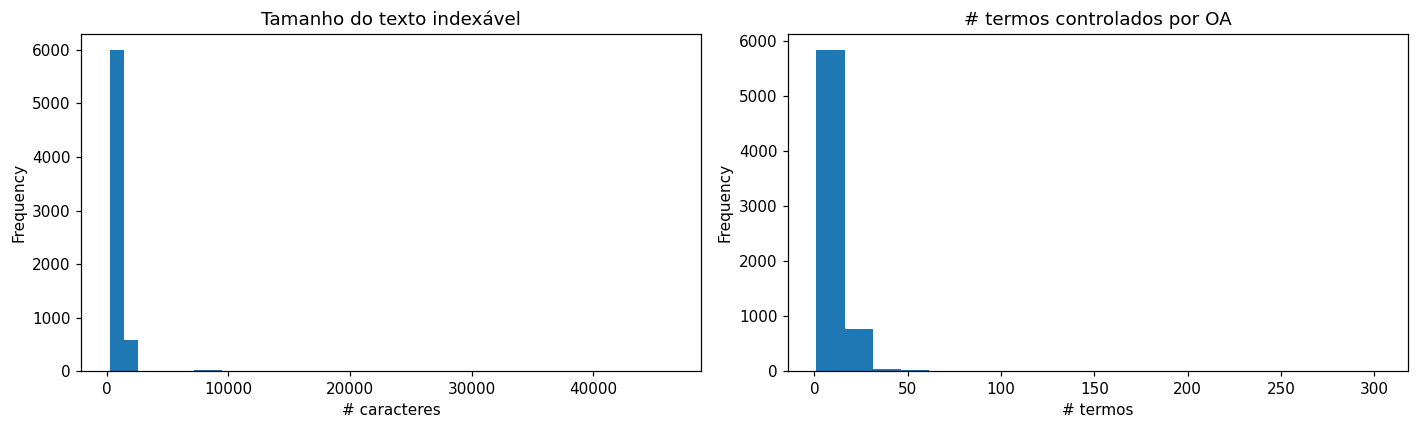

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

pd.Series([len(d['texto']) for d in corpus]).plot(
    kind='hist',
    bins=40,
    ax=ax[0],
    title='Tamanho do texto indexável'
)
ax[0].set_xlabel('# caracteres')

pd.Series([len(d['metadata']['termos_controlados']) for d in corpus]).plot(
    kind='hist',
    bins=20,
    ax=ax[1],
    title='# termos controlados por OA'
)
ax[1].set_xlabel('# termos')

plt.tight_layout()
plt.savefig(OUT / 'corpus' / 'distribuicao_v8.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print(f'Codificando {len(corpus)} OAs...')
t0 = time.time()
corpus_embs = bi_encoder.encode(
    [d['texto'] for d in corpus],
    batch_size=64,
    show_progress_bar=True
)
print(f'OK — {corpus_embs.shape} em {time.time()-t0:.0f}s')

Codificando 6683 OAs...


Batches:   0%|          | 0/105 [00:00<?, ?it/s]

OK — (6683, 384) em 32s


In [ ]:
from rank_bm25 import BM25Okapi

def simple_tokenize(t):
    t = unicodedata.normalize('NFD', t.lower())
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')
    return re.findall(r'\b[a-z0-9]+\b', t)

print('Indexando BM25...')
corpus_tokens = [simple_tokenize(d['texto']) for d in corpus]
bm25 = BM25Okapi(corpus_tokens, k1=1.5, b=0.75)
print(f'BM25: {len(corpus_tokens)} docs indexados')

Indexando BM25...
BM25: 6683 docs indexados


## 9. Enriquecimento pedagógico de cada OA

Para cada OA, extraímos:

1. **Conceitos detectados** via 3 métodos em cascata, do mais confiável ao menos:
   - (a) Match estruturado forte: `anchors` do conceito aparecem em `Termos controlados`, `Palavras-chave`, `Temas` ou `Dimensões` do OA.
   - (b) Match estruturado fraco: variações ou aliases aparecem.
   - (c) Fallback semântico: similaridade com nome do conceito ≥ threshold (limitado a 1 conceito por OA para evitar ruído).

2. **Nível ontológico** — média ponderada dos níveis dos conceitos detectados, ponderada pela confiança do match.

3. **Similaridade pré-computada** com os 7 perfis "para avançar" (sinal `s_avancar` no reranker).

> **Nota de cobertura (consistência com o artigo).** A célula de código abaixo já reporta, sobre os **6.683 OAs** do pool efetivo: **cobertura de conceitos** (OAs com ≥1 conceito detectado) e **média de conceitos/OA = 2.66** (mediana 3.0). O texto do artigo (§4.3) cita "93.7% com ≥1 conceito" e "média de 4.6 conceitos/OA". O **denominador (6.683)** já está alinhado; resta reconciliar o par **93.7% / 4.6** com o valor produzido aqui (2.66) — provavelmente diferença de definição (p.ex. contagem antes do corte por confiança do match). Use o número da saída executada como fonte da verdade ao finalizar o §4.3.

In [ ]:
import re
import unicodedata
import numpy as np
from typing import List, Tuple, Set

def norm_text(s: str) -> str:
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    s = re.sub(r'\s+', ' ', s)
    return s

concepts = list(ONTOLOGIA.keys())
concept_prompt = [f'conceito pedagógico de gestão escolar: {c}' for c in concepts]
concept_embs = bi_encoder.encode(
    concept_prompt,
    batch_size=32,
    show_progress_bar=False
)

def _collect_field_norm(m, field):
    value = m.get(field, [])
    if isinstance(value, list):
        return [norm_text(x) for x in value if x]
    if value:
        return [norm_text(value)]
    return []

def concept_match_structured(doc) -> List[Tuple[str, float, str]]:
    m = doc['metadata']

    structured_fields = []
    for field in ['termos_controlados', 'palavras_chave', 'temas', 'dimensoes']:
        structured_fields.extend(_collect_field_norm(m, field))

    weak_text = ' || '.join([
        norm_text(m.get('titulo', '')),
        norm_text(m.get('descricao_livre', ''))
    ])

    structured_blob = ' || '.join(structured_fields)
    hits = []

    for conceito, meta in ONTOLOGIA.items():
        anchors = [norm_text(a) for a in meta.get('anchors', []) if a]
        aliases = [norm_text(a) for a in meta.get('aliases', []) if a]
        cname = norm_text(conceito)

        best = 0.0
        reasons = []

        # 1) âncoras nos metadados curados: sinal forte
        for a in anchors:
            if a and a in structured_blob:
                best = max(best, 1.00)
                reasons.append(f'anchor:{a}')

        # 2) aliases nos metadados curados: sinal médio
        if best < 1.0:
            for a in aliases:
                if a and a in structured_blob:
                    best = max(best, 0.90)
                    reasons.append(f'alias:{a}')

        # 3) conceito no título/descrição: sinal fraco
        if best == 0.0:
            for a in [cname] + aliases[:2]:
                if a and a in weak_text:
                    best = max(best, 0.72)
                    reasons.append(f'texto:{a}')

        # 4) não aceitar matches muito genéricos em campos fracos
        if best >= 0.72:
            hits.append((conceito, float(best), ', '.join(sorted(set(reasons))[:3])))

    hits.sort(key=lambda x: (-x[1], x[0]))
    return hits[:CONFIG.get('conceito_top_n', 4)]

def concept_match_semantic(doc_idx: int, already: Set[str]) -> List[Tuple[str, float, str]]:
    row = corpus_embs[doc_idx] @ concept_embs.T
    order = np.argsort(-row)
    out = []

    for i in order:
        conceito = concepts[i]
        if conceito in already:
            continue

        score = float(row[i])
        if score < CONFIG.get('conceito_threshold', 0.44):
            continue

        out.append((conceito, score, 'fallback_semantico'))
        if len(out) >= CONFIG.get('fallback_semantico_max', 1):
            break

    return out

def nivel_ontologico(conceitos):
    if not conceitos:
        return 4.0
    items = [(G.nodes[c]['nivel'], s) for c, s, _ in conceitos if c in G.nodes]
    if not items:
        return 4.0
    return float(np.average([x[0] for x in items], weights=[x[1] for x in items]))

def build_structured_profiles():
    perfis = {}
    for n in sorted(DEVOLUTIVAS):
        current = {c for c, meta in ONTOLOGIA.items() if meta['nivel'] == n}
        next_level = {c for c, meta in ONTOLOGIA.items() if meta['nivel'] == min(7, n + 1)}
        target = sorted(current | next_level)
        prereqs = sorted(transitive_prereqs(target, G))
        areas = sorted({ONTOLOGIA[c]['area_mec'] for c in target if c in ONTOLOGIA})
        perfis[n] = {
            'conceitos_alvo': target,
            'prerequisitos': prereqs,
            'areas': areas,
            'dimensoes': list(CONFIG['dimensoes_alvo']),
        }
    return perfis

PERFIS = build_structured_profiles()
NIVEIS = sorted(PERFIS)

for i, d in enumerate(corpus):
    hits = concept_match_structured(d)
    nomes = {c for c, _, _ in hits}
    if len(hits) < max(1, CONFIG.get('conceito_top_n', 4) - 1):
        hits += concept_match_semantic(i, nomes)
    hits = sorted(hits, key=lambda x: -x[1])[:CONFIG.get('conceito_top_n', 4)]

    nivel = nivel_ontologico(hits)
    areas = sorted({ONTOLOGIA[c]['area_mec'] for c, _, _ in hits if c in ONTOLOGIA})

    d['metadata']['conceitos_detectados'] = hits
    d['metadata']['conceitos_nomes'] = [c for c, _, _ in hits]
    d['metadata']['conceitos_fontes'] = [f for _, _, f in hits]
    d['metadata']['nivel_oa'] = nivel
    d['metadata']['areas_mec'] = areas

conc_counts = [len(d['metadata']['conceitos_nomes']) for d in corpus]
niveis = [d['metadata']['nivel_oa'] for d in corpus]

print(f'OAs com ≥1 conceito: {sum(1 for c in conc_counts if c > 0)}/{len(corpus)} ({100*np.mean([c > 0 for c in conc_counts]):.1f}%)')
print(f'Média de conceitos por OA: {np.mean(conc_counts):.2f}')
print(f'Nível ontológico: μ={np.mean(niveis):.2f}  σ={np.std(niveis):.2f}')
for n in NIVEIS:
    print(f'N{n}: alvo={PERFIS[n]["conceitos_alvo"][:3]}... áreas={PERFIS[n]["areas"]}')

OAs com ≥1 conceito: 6494/6683 (97.2%)
Média de conceitos por OA: 2.66
Nível ontológico: μ=4.48  σ=1.16
N1: alvo=['avaliação diagnóstica', 'mediação pedagógica', 'objetivos institucionais e metas']... áreas=['A1', 'A2', 'A3', 'A4']
N2: alvo=['avaliação diagnóstica', 'bncc e currículo', 'dados de aprendizagem e indicadores']... áreas=['A1', 'A2', 'A3', 'A4']
N3: alvo=['apoio e suporte aos professores', 'bncc e currículo', 'dados de aprendizagem e indicadores']... áreas=['A1', 'A2', 'A3', 'A4']
N4: alvo=['acompanhamento sistemático de resultados', 'apoio e suporte aos professores', 'devolutivas e feedback docente']... áreas=['A2', 'A3', 'A4']
N5: alvo=['acompanhamento sistemático de resultados', 'autonomia docente', 'diagnóstico de práticas docentes']... áreas=['A1', 'A2', 'A3', 'A4']
N6: alvo=['autonomia docente', 'cultura escolar e clima institucional', 'envolvimento da comunidade escolar']... áreas=['A1', 'A3', 'A4', 'A5', 'A6']
N7: alvo=['cultura escolar e clima institucional', 'envo

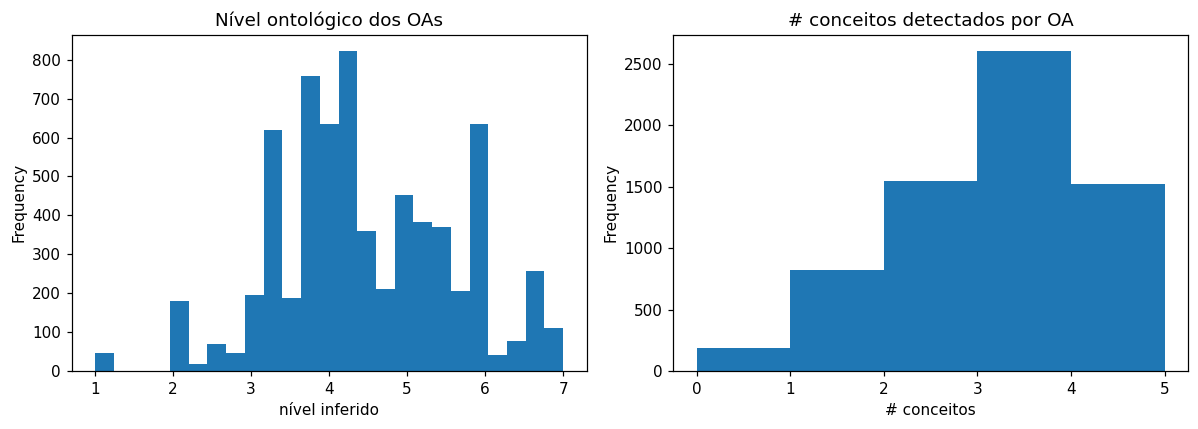

Corpus: 6683 OAs com pelo menos 1 conceito detectado.
Média de conceitos/OA: 2.66; mediana: 3.0


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(niveis).plot(kind='hist', bins=25, ax=ax[0], title='Nível ontológico dos OAs')
ax[0].set_xlabel('nível inferido')
pd.Series(conc_counts).plot(kind='hist', bins=range(0, 6), ax=ax[1], title='# conceitos detectados por OA')
ax[1].set_xlabel('# conceitos')
plt.tight_layout()
plt.savefig(OUT / 'corpus' / 'distribuicao_v8.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Corpus: {len(corpus)} OAs com pelo menos 1 conceito detectado.')
print(f'Média de conceitos/OA: {np.mean(conc_counts):.2f}; mediana: {np.median(conc_counts):.1f}')


## 10. Stage 1 — retrieval híbrido (BM25 + Dense + RRF)

In [ ]:
def dense_retrieve(query, top_k):
    q = bi_encoder.encode(query, batch_size=1, show_progress_bar=False)[0]
    sims = corpus_embs @ q
    idx = np.argsort(-sims)[:top_k]
    return [(int(i), float(sims[i])) for i in idx]

def bm25_retrieve(query, top_k):
    scores = bm25.get_scores(simple_tokenize(query))
    idx = np.argsort(-scores)[:top_k]
    return [(int(i), float(scores[i])) for i in idx]

def rrf_fuse(rankings, k=60):
    scores = defaultdict(float)
    for r in rankings:
        for rank, (idx, _) in enumerate(r, 1):
            scores[idx] += 1.0 / (k + rank)
    return sorted(scores.items(), key=lambda x: -x[1])

def hybrid_retrieve(query, top_k):
    mult = 2
    d = dense_retrieve(query, top_k * mult)
    b = bm25_retrieve(query, top_k * mult)
    return rrf_fuse([d, b], k=CONFIG.get('rrf_k', 60))[:top_k]

print('Stage 1 pronto.')


Stage 1 pronto.


## 11. Stage 2 — Cross-encoder multilíngue

`BAAI/bge-reranker-v2-m3` em GPU, `bge-reranker-base` como fallback em CPU. Processa query+documento em atenção cruzada (diferente do bi-encoder que processa separado).

In [ ]:
from FlagEmbedding import FlagReranker

cross_encoder_name = CONFIG.get('cross_encoder', 'BAAI/bge-reranker-base')

print(f'Carregando cross-encoder: {cross_encoder_name}...')
try:
    cross_encoder = FlagReranker(cross_encoder_name, use_fp16=True)
    print('✓ Cross-encoder carregado')
except Exception as e:
    print(f'Fallback para fp32/modelo padrão: {e}')
    try:
        cross_encoder = FlagReranker(cross_encoder_name, use_fp16=False)
        print('✓ Cross-encoder carregado em fp32')
    except Exception as e2:
        print(f'Fallback final para BAAI/bge-reranker-base: {e2}')
        cross_encoder = FlagReranker('BAAI/bge-reranker-base', use_fp16=False)
        print('✓ Cross-encoder padrão carregado')

def cross_encoder_rerank(query, candidates_idx, top_k):
    if not candidates_idx:
        return []

    pairs = [[query, corpus[i]['texto'][:2000]] for i in candidates_idx]
    scores = cross_encoder.compute_score(pairs, normalize=True)
    if isinstance(scores, float):
        scores = [scores]

    scored = sorted(zip(candidates_idx, scores), key=lambda x: -x[1])
    return [(i, float(s)) for i, s in scored[:top_k]]


Carregando cross-encoder: BAAI/bge-reranker-base...
✓ Cross-encoder carregado


## 12. Stage 3 — Pedagogical reranker (6 sinais)

Sinais z-normalizados e combinados linearmente com os pesos definidos em CONFIG:

- `s_cross` — score do cross-encoder
- `s_avancar` — similaridade com texto "para avançar" do nível do gestor (perfil estruturado)
- `s_preq` — cobertura de pré-requisitos na ontologia
- `s_las` — Level Alignment Score (adequação ordinal de nível)
- `s_area_mec` — alinhamento com área da Matriz do MEC relevante ao nível
- `s_dim` / `s_formato` — metadados estruturados

## 13. Pipelines comparados

| Sistema | Stage 1 | Stage 2 | Stage 3 | Objetivo |
|---|---|---|---|---|
| **S1** BM25 | BM25 | — | — | Baseline esparso |
| **S2** Dense | Bi-encoder | — | — | Baseline denso |
| **S3** Hybrid | BM25+Dense (RRF) | — | — | Fusão SOTA IR |
| **S4** Hybrid+Cross | BM25+Dense | Cross-encoder | — | **SOTA IR** (referência) |
| **S5** Proposto | BM25+Dense | Cross-encoder | **Pedagogical (6 sinais)** | Sistema completo |
| **A1** Sem perfil | ... | ... | Sem `s_avancar` | Isola perfil |
| **A2** Sem ontologia | ... | ... | Sem `s_preq + s_las + s_area_mec` | Isola ontologia |
| **A3** Sem metadados | ... | ... | Sem `s_dim + s_formato` | Isola metadados |

In [ ]:
def pipeline_bm25(q, n, k):
    return bm25_retrieve(q, k)

def pipeline_dense(q, n, k):
    return dense_retrieve(q, k)

def pipeline_hybrid(q, n, k):
    return hybrid_retrieve(q, k)

def pipeline_hybrid_cross(q, n, k):
    retrieval_k = CONFIG.get('retrieval_top_k', CONFIG.get('top_k_retrieval', 80))
    rerank_k = CONFIG.get('rerank_top_k', CONFIG.get('top_k_rerank', 20))
    cands = hybrid_retrieve(q, retrieval_k)
    cand_idx = [i for i, _ in cands][:rerank_k]
    return cross_encoder_rerank(q, cand_idx, k)

def pipeline_proposto(q, n, k, w=None):
    weights = w or CONFIG.get('ped_weights')
    if weights is None:
        weights = {
            'cross': 0.56,
            'perfil_estruturado': 0.10,
            'prerequisitos': 0.12,
            'las': 0.10,
            'area_mec': 0.06,
            'dimensao': 0.03,
            'formato': 0.03,
        }

    retrieval_k = CONFIG.get('retrieval_top_k', CONFIG.get('top_k_retrieval', 80))
    rerank_k = CONFIG.get('rerank_top_k', CONFIG.get('top_k_rerank', 20))
    cands = hybrid_retrieve(q, retrieval_k)
    cand_idx = [i for i, _ in cands][:rerank_k]
    cross_scored = cross_encoder_rerank(q, cand_idx, rerank_k)
    ped_scored = pedagogical_rerank(cross_scored, n, weights)[:k]
    return [(s.idx, s.s_final) for s in ped_scored], ped_scored

def pipeline_ablation(q, n, k, remove):
    w = dict(CONFIG.get('ped_weights', {}))
    if remove == 'perfil':
        w['perfil_estruturado'] = 0.0
    if remove == 'ontologia':
        w['prerequisitos'] = 0.0
        w['las'] = 0.0
        w['area_mec'] = 0.0
    if remove == 'metadados':
        w['area_mec'] = 0.0
        w['dimensao'] = 0.0
        w['formato'] = 0.0

    s = sum(w.values())
    if s <= 0:
        raise ValueError('Pesos inválidos após ablação.')
    w = {k_: v / s for k_, v in w.items()}
    return pipeline_proposto(q, n, k, w=w)

print('Pipelines prontos.')

Pipelines prontos.


## 14. Queries sintéticas — 25 perguntas, ~4 por nível

Derivadas dos textos "para avançar" das devolutivas. Cada query tem um `conceito_alvo` da ontologia.

**Limitação declarada:** queries são sintéticas e derivadas da mesma rubrica que estrutura o sistema. Isso introduz viés de construção. Pooling humano com logs reais é o próximo passo (trabalho futuro explicitamente declarado).

In [ ]:
QUERIES_POR_NIVEL = {
    1: [
        ('o que é planejamento pedagógico?', 'planejamento pedagógico'),
        ('como organizar rotinas e calendário escolar do planejamento?', 'rotinas e calendário escolar'),
        ('como organizar tempos e espaços pedagógicos?', 'organização de tempos e espaços pedagógicos'),
        ('o que é recomposição de aprendizagens?', 'recomposição de aprendizagens'),
    ],
    2: [
        ('como fazer mediação pedagógica no planejamento?', 'mediação pedagógica'),
        ('o que é planejamento colaborativo?', 'planejamento colaborativo'),
        ('como conectar planejamento a objetivos institucionais e metas?', 'objetivos institucionais e metas'),
        ('como usar avaliação diagnóstica no planejamento?', 'avaliação diagnóstica'),
    ],
    3: [
        ('como usar dados de aprendizagem e indicadores no planejamento?', 'dados de aprendizagem e indicadores'),
        ('como conduzir discussões pedagógicas e formação continuada com professores?', 'discussões pedagógicas e formação continuada'),
        ('como alinhar planejamento a diretrizes e políticas educacionais?', 'diretrizes e políticas educacionais'),
        ('como conectar BNCC e currículo ao planejamento?', 'bncc e currículo'),
    ],
    4: [
        ('como estruturar monitoramento do planejamento?', 'monitoramento do planejamento'),
        ('o que é replanejamento pedagógico?', 'replanejamento pedagógico'),
        ('como oferecer devolutivas e feedback docente?', 'devolutivas e feedback docente'),
        ('como apoiar os professores de forma consistente?', 'apoio e suporte aos professores'),
    ],
    5: [
        ('como exercer liderança pedagógica no processo de planejamento?', 'liderança pedagógica'),
        ('como diagnosticar práticas docentes?', 'diagnóstico de práticas docentes'),
        ('como fazer acompanhamento sistemático de resultados?', 'acompanhamento sistemático de resultados'),
    ],
    6: [
        ('como alinhar planejamento ao projeto político-pedagógico da escola?', 'projeto político-pedagógico'),
        ('como promover interdisciplinaridade no currículo?', 'interdisciplinaridade'),
        ('como fortalecer autonomia docente?', 'autonomia docente'),
    ],
    7: [
        ('como incorporar inovação pedagógica e metodologias ativas?', 'inovação pedagógica e metodologias ativas'),
        ('como consolidar cultura escolar e clima institucional?', 'cultura escolar e clima institucional'),
        ('como ampliar o envolvimento da comunidade escolar?', 'envolvimento da comunidade escolar'),
    ],
}

queries = []
for n, items in QUERIES_POR_NIVEL.items():
    for i, (q, alvo) in enumerate(items, 1):
        queries.append({
            'query_id': f'N{n}_Q{i}',
            'nivel': n,
            'query': q,
            'conceito_alvo': alvo,
        })
queries_df = pd.DataFrame(queries)
print(f'{len(queries_df)} queries')
queries_df.head(10)

25 queries


,query_id,nivel,query,conceito_alvo
0,N1_Q1,1,o que é planejamento pedagógico?,planejamento pedagógico
1,N1_Q2,1,como organizar rotinas e calendário escolar do...,rotinas e calendário escolar
2,N1_Q3,1,como organizar tempos e espaços pedagógicos?,organização de tempos e espaços pedagógicos
3,N1_Q4,1,o que é recomposição de aprendizagens?,recomposição de aprendizagens
4,N2_Q1,2,como fazer mediação pedagógica no planejamento?,mediação pedagógica
5,N2_Q2,2,o que é planejamento colaborativo?,planejamento colaborativo
6,N2_Q3,2,como conectar planejamento a objetivos institu...,objetivos institucionais e metas
7,N2_Q4,2,como usar avaliação diagnóstica no planejamento?,avaliação diagnóstica
8,N3_Q1,3,como usar dados de aprendizagem e indicadores ...,dados de aprendizagem e indicadores
9,N3_Q2,3,como conduzir discussões pedagógicas e formaçã...,discussões pedagógicas e formação continuada


## 15. Métricas — IR padrão + domain-specific

**Gold topical** (relevância pura): `concept_hit`. Um OA é topicamente relevante se detectamos nele o conceito alvo da query.

**Gold pedagógico** (composto): `0.45 · concept_hit + 0.18 · prereq + 0.17 · LAS + 0.10 · area_mec + 0.10 · dimensao`. Combina relevância tópica com adequação pedagógica. (Esta é a fórmula efetivamente usada em `build_gold_ped`; ver também o §24.)

**Métricas IR** (calculadas sobre ambos os golds):
- NDCG@k (k ∈ {5, 10})
- MRR@10
- Precision@k, Recall@k

**Métricas domain-specific** (independentes dos golds):
- LAS@k — média do LAS dos OAs no top-k
- PGS@k — fração de OAs do top-k em nível pedagogicamente adequado

Reportamos **três variantes de NDCG** com grau crescente de acoplamento ao gold pedagógico: **NDCG_top** (gold topical, limpo) < **NDCG_ped_nolas** (composto sem o termo LAS, §24) < **NDCG_ped** (composto completo). A variante desacoplada quebra a circularidade do sinal `s_las` otimizado por S5.

In [ ]:
def concept_hit(doc, target):
    cs = doc['metadata']['conceitos_nomes']
    if target in cs:
        for c, s, _ in doc['metadata']['conceitos_detectados']:
            if c == target:
                return min(1.0, s)
        return 1.0
    return 0.0

def build_gold_ped(target, n_gestor):
    dom = conceitos_dominados_do_nivel(n_gestor)
    rels = []
    for d in corpus:
        m = d['metadata']
        co = concept_hit(d, target)
        pc = prereq_score(m['conceitos_nomes'], dom)
        la = las_score(m['nivel_oa'], n_gestor)
        ar = area_mec_score(m.get('areas_mec', []), n_gestor)
        di = dimensao_score(m.get('dimensoes', []))
        rels.append(0.45*co + 0.18*pc + 0.17*la + 0.10*ar + 0.10*di)
    return np.array(rels)

def build_gold_top(target):
    return np.array([concept_hit(d, target) for d in corpus])

def ndcg_at_k(rank, gold, k):
    rels = np.array([gold[i] for i in rank[:k]])
    dcg = float(np.sum((2**rels - 1) / np.log2(np.arange(2, len(rels)+2))))
    ideal = np.sort(gold)[::-1][:k]
    idcg = float(np.sum((2**ideal - 1) / np.log2(np.arange(2, len(ideal)+2))))
    return dcg / idcg if idcg > 0 else 0.0

def mrr_at_k(rank, gold, k, thr=0.4):
    for i, idx in enumerate(rank[:k], 1):
        if gold[idx] >= thr:
            return 1.0 / i
    return 0.0

def precision_at_k(rank, gold, k, thr=0.4):
    return float(np.mean([gold[i] >= thr for i in rank[:k]]))

def recall_at_k(rank, gold, k, thr=0.4):
    rel = int(np.sum(gold >= thr))
    if rel == 0:
        return 0.0
    return sum(1 for i in rank[:k] if gold[i] >= thr) / min(rel, k)

def las_at_k(rank, n_g, k):
    return float(np.mean([las_score(corpus[i]['metadata']['nivel_oa'], n_g) for i in rank[:k]]))

def pgs_at_k(rank, n_g, k):
    c = sum(1 for i in rank[:k] if -0.5 <= (corpus[i]['metadata']['nivel_oa'] - n_g) <= 1.0)
    return c / k

print('Métricas definidas.')

Métricas definidas.


## 16. Experimento principal — 8 sistemas × 25 queries

In [ ]:
final_top_k = CONFIG.get('final_top_k', CONFIG.get('top_k_final', 10))
ndcg_k_list = CONFIG.get('ndcg_k', [5, 10])
mrr_k = CONFIG.get('mrr_k', 10)

SISTEMAS = {
    'S1_BM25':          pipeline_bm25,
    'S2_Dense':         pipeline_dense,
    'S3_Hybrid':        pipeline_hybrid,
    'S4_Hybrid_Cross':  pipeline_hybrid_cross,
    'S5_Proposto_V9':   lambda q, n, k: pipeline_proposto(q, n, k)[0],
    'A1_Sem_Perfil':    lambda q, n, k: pipeline_ablation(q, n, k, 'perfil')[0],
    'A2_Sem_Ontologia': lambda q, n, k: pipeline_ablation(q, n, k, 'ontologia')[0],
    'A3_Sem_Metadados': lambda q, n, k: pipeline_ablation(q, n, k, 'metadados')[0],
}

rows_met, rows_rank, rows_err = [], [], []
t0 = time.time()

for qi, qrow in queries_df.iterrows():
    q = qrow['query']
    qid = qrow['query_id']
    n_q = int(qrow['nivel'])
    tgt = qrow['conceito_alvo']

    gold_ped = build_gold_ped(tgt, n_q)
    gold_top = build_gold_top(tgt)

    for sname, fn in SISTEMAS.items():
        try:
            result = fn(q, n_q, final_top_k)
            rank_idx = [i for i, _ in result]
        except Exception as e:
            rows_err.append({'query_id': qid, 'sistema': sname, 'erro': repr(e)})
            print(f'[!] {sname} {qid}: {e}')
            continue

        for i, (idx, sc) in enumerate(result[:5], 1):
            d = corpus[idx]
            m = d['metadata']
            rows_rank.append({
                'query_id': qid,
                'query': q,
                'nivel_gestor': n_q,
                'sistema': sname,
                'rank': i,
                'doc_id': d['id'],
                'titulo': str(m.get('titulo', ''))[:120],
                'url': m.get('url', ''),
                'nivel_oa': round(float(m.get('nivel_oa', 0.0)), 2),
                'score': float(sc),
                'conceitos': '; '.join(m.get('conceitos_nomes', [])[:3]),
                'areas_mec': '; '.join(m.get('areas_mec', [])),
                'dimensoes': '; '.join(m.get('dimensoes', [])),
            })

        for k in ndcg_k_list:
            rows_met.append({
                'query_id': qid,
                'nivel_gestor': n_q,
                'sistema': sname,
                'k': k,
                'ndcg_ped': ndcg_at_k(rank_idx, gold_ped, k),
                'ndcg_top': ndcg_at_k(rank_idx, gold_top, k),
                'mrr': mrr_at_k(rank_idx, gold_ped, mrr_k),
                'precision': precision_at_k(rank_idx, gold_ped, k),
                'recall': recall_at_k(rank_idx, gold_ped, k),
                'LAS': las_at_k(rank_idx, n_q, k),
                'PGS': pgs_at_k(rank_idx, n_q, k),
            })

    if (qi + 1) % 5 == 0:
        print(f'  {qi+1}/{len(queries_df)} ({time.time()-t0:.0f}s)')

rankings_df = pd.DataFrame(rows_rank)
metricas_df = pd.DataFrame(rows_met)
erros_df = pd.DataFrame(rows_err)

rankings_df.to_csv(OUT / 'rankings' / 'rankings_v9.csv', index=False, encoding='utf-8')
metricas_df.to_csv(OUT / 'metricas' / 'metricas_v9.csv', index=False, encoding='utf-8')
if len(erros_df):
    erros_df.to_csv(OUT / 'metricas' / 'erros_execucao_v9.csv', index=False, encoding='utf-8')

print(f'Experimento concluído em {(time.time()-t0)/60:.1f} min')
print('rankings_df:', rankings_df.shape)
print('metricas_df:', metricas_df.shape)
print('erros_df:', erros_df.shape)
display(metricas_df.head())


  5/25 (6s)
  10/25 (13s)
  15/25 (19s)
  20/25 (25s)
  25/25 (30s)
Experimento concluído em 0.5 min
rankings_df: (1000, 13)
metricas_df: (400, 11)
erros_df: (0, 0)


,query_id,nivel_gestor,sistema,k,ndcg_ped,ndcg_top,mrr,precision,recall,LAS,PGS
0,N1_Q1,1,S1_BM25,5,0.407304,0.242139,1.0,0.2,0.2,0.30,0.0
1,N1_Q1,1,S1_BM25,10,0.353847,0.157131,1.0,0.1,0.1,0.25,0.0
2,N1_Q1,1,S2_Dense,5,0.348803,0.152773,0.5,0.2,0.2,0.30,0.0
3,N1_Q1,1,S2_Dense,10,0.337136,0.138760,0.5,0.2,0.2,0.25,0.0
4,N1_Q1,1,S3_Hybrid,5,0.423112,0.242139,1.0,0.2,0.2,0.30,0.0


## 17. Tabelas principais (visão geral)

Quatro tabelas clássicas de avaliação:

- **Tabela A**: métricas médias por sistema em k=10.
- **Tabela B**: NDCG@5 pedagógico por nível do gestor (heterogeneidade).
- **Tabela C**: ganhos do sistema proposto sobre cada baseline.
- **Tabela D**: ablação dos 3 blocos pedagógicos (perfil, ontologia, metadados).

In [ ]:
ORDER = [
    'S1_BM25', 'S2_Dense', 'S3_Hybrid', 'S4_Hybrid_Cross',
    'S5_Proposto_V9', 'A1_Sem_Perfil', 'A2_Sem_Ontologia', 'A3_Sem_Metadados'
]

tab_base = (
    metricas_df[metricas_df['k'] == 10]
    .groupby('sistema')[['ndcg_ped', 'ndcg_top', 'mrr', 'precision', 'recall', 'LAS', 'PGS']]
    .mean()
    .round(3)
)

TAB_A = tab_base.reindex(ORDER)
TAB_A.to_csv(OUT / 'metricas' / 'tabela_A_k10_v9.csv', encoding='utf-8')

print('=== Tabela A — métricas @ k=10 ===')
display(TAB_A)

print("Sistemas presentes em metricas_df:")
print(sorted(metricas_df['sistema'].unique().tolist()))
print()

print("Contagem de linhas por sistema:")
display(metricas_df.groupby('sistema').size().sort_index())

print()
print("Contagem de linhas por sistema em k=10:")
display(metricas_df[metricas_df['k'] == 10].groupby('sistema').size().sort_index())


=== Tabela A — métricas @ k=10 ===


,ndcg_ped,ndcg_top,mrr,precision,recall,LAS,PGS
sistema,,,,,,,
S1_BM25,0.624,0.573,0.879,0.704,0.704,0.593,0.292
S2_Dense,0.571,0.493,0.788,0.628,0.628,0.539,0.244
S3_Hybrid,0.626,0.584,0.855,0.692,0.692,0.563,0.284
S4_Hybrid_Cross,0.647,0.627,0.828,0.712,0.712,0.567,0.292
S5_Proposto_V9,0.704,0.668,0.858,0.784,0.784,0.662,0.396
A1_Sem_Perfil,0.696,0.651,0.858,0.780,0.780,0.672,0.416
A2_Sem_Ontologia,0.681,0.662,0.848,0.760,0.760,0.612,0.332
A3_Sem_Metadados,0.701,0.665,0.858,0.784,0.784,0.676,0.416


Sistemas presentes em metricas_df:
['A1_Sem_Perfil', 'A2_Sem_Ontologia', 'A3_Sem_Metadados', 'S1_BM25', 'S2_Dense', 'S3_Hybrid', 'S4_Hybrid_Cross', 'S5_Proposto_V9']

Contagem de linhas por sistema:


,0
sistema,
A1_Sem_Perfil,50
A2_Sem_Ontologia,50
A3_Sem_Metadados,50
S1_BM25,50
S2_Dense,50
S3_Hybrid,50
S4_Hybrid_Cross,50
S5_Proposto_V9,50



Contagem de linhas por sistema em k=10:


,0
sistema,
A1_Sem_Perfil,25
A2_Sem_Ontologia,25
A3_Sem_Metadados,25
S1_BM25,25
S2_Dense,25
S3_Hybrid,25
S4_Hybrid_Cross,25
S5_Proposto_V9,25


In [ ]:
TAB_B = (
    metricas_df[metricas_df.k == 5]
    .pivot_table(index='sistema', columns='nivel_gestor', values='ndcg_ped', aggfunc='mean')
    .round(3)
    .reindex(ORDER)
)
TAB_B.to_csv(OUT / 'metricas' / 'tabela_B_ndcg5_por_nivel_v8.csv', encoding='utf-8')
print('=== Tabela B — NDCG@5 ped por nível ===')
display(TAB_B)


=== Tabela B — NDCG@5 ped por nível ===


nivel_gestor,1,2,3,4,5,6,7
sistema,,,,,,,
S1_BM25,0.517,0.533,0.737,0.522,0.651,0.722,0.811
S2_Dense,0.313,0.392,0.727,0.552,0.679,0.646,0.817
S3_Hybrid,0.451,0.494,0.786,0.575,0.674,0.773,0.838
S4_Hybrid_Cross,0.462,0.491,0.815,0.600,0.708,0.753,0.837
S5_Proposto_V9,0.560,0.659,0.831,0.689,0.788,0.765,0.900
A1_Sem_Perfil,0.559,0.588,0.823,0.661,0.735,0.762,0.898
A2_Sem_Ontologia,0.517,0.570,0.819,0.632,0.743,0.779,0.874
A3_Sem_Metadados,0.543,0.615,0.829,0.659,0.758,0.765,0.888


In [ ]:
m10 = metricas_df[metricas_df.k == 10].groupby('sistema')[['ndcg_ped', 'mrr', 'LAS', 'PGS']].mean()

def diff_vs(ref, comp):
    if ref not in m10.index or comp not in m10.index:
        return pd.Series({c: np.nan for c in ['ndcg_ped', 'mrr', 'LAS', 'PGS']})
    return (m10.loc[ref] - m10.loc[comp]).round(3)

TAB_C = pd.DataFrame({
    'Δ vs BM25':   diff_vs('S5_Proposto_V9', 'S1_BM25'),
    'Δ vs Dense':  diff_vs('S5_Proposto_V9', 'S2_Dense'),
    'Δ vs Hybrid': diff_vs('S5_Proposto_V9', 'S3_Hybrid'),
    'Δ vs +Cross': diff_vs('S5_Proposto_V9', 'S4_Hybrid_Cross'),
})
TAB_C.to_csv(OUT / 'metricas' / 'tabela_C_ganhos_v9.csv', encoding='utf-8')
print('=== Tabela C — ganhos do sistema proposto ===')
display(TAB_C)


=== Tabela C — ganhos do sistema proposto ===


,Δ vs BM25,Δ vs Dense,Δ vs Hybrid,Δ vs +Cross
ndcg_ped,0.080,0.133,0.078,0.058
mrr,-0.021,0.070,0.003,0.030
LAS,0.070,0.123,0.100,0.095
PGS,0.104,0.152,0.112,0.104


In [ ]:
def row_or_nan(system_name):
    if system_name not in m10.index:
        return pd.Series({c: np.nan for c in ['ndcg_ped', 'mrr', 'LAS', 'PGS']})
    return m10.loc[system_name].round(3)

TAB_D = pd.DataFrame({
    'S5_Proposto_V9':      row_or_nan('S5_Proposto_V9'),
    'perda_sem_perfil':    diff_vs('S5_Proposto_V9', 'A1_Sem_Perfil'),
    'perda_sem_ontologia': diff_vs('S5_Proposto_V9', 'A2_Sem_Ontologia'),
    'perda_sem_metadados': diff_vs('S5_Proposto_V9', 'A3_Sem_Metadados'),
})
TAB_D.to_csv(OUT / 'metricas' / 'tabela_D_ablacao_v9.csv', encoding='utf-8')
print('=== Tabela D — ablação ===')
display(TAB_D)


=== Tabela D — ablação ===


,S5_Proposto_V9,perda_sem_perfil,perda_sem_ontologia,perda_sem_metadados
ndcg_ped,0.704,0.008,0.023,0.004
mrr,0.858,0.000,0.010,0.000
LAS,0.662,-0.010,0.050,-0.013
PGS,0.396,-0.020,0.064,-0.020


In [ ]:
s5 = metricas_df[(metricas_df.sistema == 'S5_Proposto_V9') & (metricas_df.k == 10)].set_index('query_id')['ndcg_ped']
s4 = metricas_df[(metricas_df.sistema == 'S4_Hybrid_Cross') & (metricas_df.k == 10)].set_index('query_id')['ndcg_ped']
common = s5.index.intersection(s4.index)

if len(common) > 5 and (s5.loc[common] - s4.loc[common]).abs().sum() > 0:
    stat, pval = wilcoxon(s5.loc[common], s4.loc[common], alternative='greater')
    print('=== Significância S5 > S4 (Wilcoxon, NDCG@10) ===')
    print(f'N queries: {len(common)}')
    print(f'Mediana S5: {s5.loc[common].median():.3f} | Mediana S4: {s4.loc[common].median():.3f}')
    print(f'Wilcoxon W={stat:.2f}, p-value={pval:.4f}')
else:
    pval = 1.0
    print('Diferenças insuficientes para Wilcoxon.')


=== Significância S5 > S4 (Wilcoxon, NDCG@10) ===
N queries: 25
Mediana S5: 0.726 | Mediana S4: 0.720
Wilcoxon W=298.00, p-value=0.0000


---

# Parte 2 — Análise estendida para o paper

A partir daqui, camada de análise nova que não existia nas versões anteriores. Cada seção gera material específico para uma parte do paper.

---

## 18. [Melhoria 1] Bootstrap CI 95% — quando uma diferença é real?

Com N=25 queries, diferenças pequenas entre sistemas podem ser ruído. Bootstrap com 2000 resamples responde objetivamente: qual é a faixa razoável para cada métrica?

**Interpretação:**
- Se o CI de dois sistemas não se sobrepõe → diferença **robusta**.
- Se os CIs se sobrepõem → diferença pode ser **ruído**, precisa de mais queries ou interpretação cautelosa.

Isso é o padrão metodológico esperado em qualquer venue sério de IR.

In [ ]:
# Bootstrap CI 95% sobre queries (1000-2000 resamples típicos na literatura)
N_BOOTSTRAP = 2000
CI_LEVEL = 0.95
rng = np.random.default_rng(42)

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=CI_LEVEL):
    """Retorna (mean, ci_lo, ci_hi) via bootstrap sobre queries."""
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        m = float(np.mean(values)) if len(values) else float('nan')
        return m, m, m
    boots = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    lo = float(np.percentile(boots, (1 - ci) / 2 * 100))
    hi = float(np.percentile(boots, (1 - (1 - ci) / 2) * 100))
    return float(np.mean(values)), lo, hi

print(f'Bootstrap {N_BOOTSTRAP} resamples, CI {int(CI_LEVEL*100)}%, N queries = {metricas_df.query_id.nunique()}')

rows_ci = []
for sistema in ORDER:
    if sistema not in metricas_df['sistema'].unique():
        continue
    sub = metricas_df[(metricas_df.sistema == sistema) & (metricas_df.k == 10)]
    for metric in ['ndcg_top', 'ndcg_ped', 'mrr', 'precision', 'recall', 'LAS', 'PGS']:
        vals = sub[metric].values
        m, lo, hi = bootstrap_ci(vals)
        rows_ci.append({
            'sistema': sistema, 'metric': metric,
            'mean': round(m, 3), 'ci_lo': round(lo, 3), 'ci_hi': round(hi, 3),
            'half_width': round((hi - lo) / 2, 3),
        })

ci_df = pd.DataFrame(rows_ci)
ci_df.to_csv(OUT / 'metricas' / 'bootstrap_ci_k10.csv', index=False, encoding='utf-8')
print('\nCI salvo em bootstrap_ci_k10.csv')
ci_df.head(10)

Bootstrap 2000 resamples, CI 95%, N queries = 25

CI salvo em bootstrap_ci_k10.csv


,sistema,metric,mean,ci_lo,ci_hi,half_width
0,S1_BM25,ndcg_top,0.573,0.454,0.685,0.115
1,S1_BM25,ndcg_ped,0.624,0.552,0.689,0.069
2,S1_BM25,mrr,0.879,0.778,0.966,0.094
3,S1_BM25,precision,0.704,0.588,0.804,0.108
4,S1_BM25,recall,0.704,0.592,0.808,0.108
5,S1_BM25,LAS,0.593,0.510,0.680,0.085
6,S1_BM25,PGS,0.292,0.184,0.400,0.108
7,S2_Dense,ndcg_top,0.493,0.350,0.627,0.138
8,S2_Dense,ndcg_ped,0.571,0.490,0.650,0.080
9,S2_Dense,mrr,0.788,0.637,0.915,0.139


In [ ]:
# Tabela principal do paper — média [CI 95%] para cada sistema em cada métrica
def fmt_ci(row):
    return f"{row['mean']:.3f} [{row['ci_lo']:.3f}, {row['ci_hi']:.3f}]"

ci_wide = ci_df.copy()
ci_wide['celula'] = ci_wide.apply(fmt_ci, axis=1)
TAB_CI = (ci_wide
    .pivot_table(index='sistema', columns='metric', values='celula', aggfunc='first')
    .reindex(ORDER)[['ndcg_top', 'ndcg_ped', 'mrr', 'LAS', 'PGS']])

TAB_CI.to_csv(OUT / 'metricas' / 'tabela_principal_com_CI.csv', encoding='utf-8')
print('=== TABELA PRINCIPAL PARA O PAPER — média [CI 95%] ===')
display(TAB_CI)

=== TABELA PRINCIPAL PARA O PAPER — média [CI 95%] ===


metric,ndcg_top,ndcg_ped,mrr,LAS,PGS
sistema,,,,,
S1_BM25,"0.573 [0.454, 0.685]","0.624 [0.552, 0.689]","0.879 [0.778, 0.966]","0.593 [0.510, 0.680]","0.292 [0.184, 0.400]"
S2_Dense,"0.493 [0.350, 0.627]","0.571 [0.490, 0.650]","0.788 [0.637, 0.915]","0.539 [0.461, 0.613]","0.244 [0.152, 0.336]"
S3_Hybrid,"0.584 [0.466, 0.704]","0.626 [0.554, 0.696]","0.855 [0.747, 0.953]","0.563 [0.479, 0.648]","0.284 [0.188, 0.392]"
S4_Hybrid_Cross,"0.627 [0.498, 0.742]","0.647 [0.572, 0.715]","0.828 [0.711, 0.928]","0.567 [0.482, 0.654]","0.292 [0.188, 0.404]"
S5_Proposto_V9,"0.668 [0.563, 0.768]","0.704 [0.639, 0.759]","0.858 [0.740, 0.950]","0.662 [0.582, 0.743]","0.396 [0.288, 0.512]"
A1_Sem_Perfil,"0.651 [0.541, 0.752]","0.696 [0.632, 0.756]","0.858 [0.748, 0.960]","0.672 [0.594, 0.754]","0.416 [0.308, 0.536]"
A2_Sem_Ontologia,"0.662 [0.539, 0.781]","0.681 [0.602, 0.752]","0.848 [0.735, 0.948]","0.612 [0.532, 0.696]","0.332 [0.220, 0.460]"
A3_Sem_Metadados,"0.665 [0.555, 0.775]","0.701 [0.639, 0.761]","0.858 [0.742, 0.950]","0.676 [0.594, 0.754]","0.416 [0.300, 0.536]"


### Nota metodológica: CI vs Wilcoxon pareado

Duas formas diferentes de avaliar se a diferença entre dois sistemas é "real":

- **Bootstrap CI**: estima a faixa provável da **média** de cada sistema isoladamente. Se os CIs **não se sobrepõem**, temos evidência forte de diferença. Se se sobrepõem, a evidência é fraca pela CI, **mas** Wilcoxon pareado ainda pode ser significativo.
- **Wilcoxon pareado** (seção 19): testa diferenças **query por query**. É mais sensível porque aproveita o pareamento — duas queries difíceis não inflam o ruído se ambos os sistemas vão mal nelas.

**Qual usar no paper:** ambos. Wilcoxon pareado diz se S5 é sistematicamente melhor que S4 na mesma query; CI diz qual a magnitude plausível do ganho. São complementares.

In [ ]:
# Diagnóstico: sobreposição de CI entre S5 e outros sistemas
# Se não sobrepõe, a diferença é robusta (mas CIs sobrepostos não descartam Wilcoxon)
print('=== Sobreposição de CI — S5 vs outros ===')
for sistema in ['S4_Hybrid_Cross', 'A1_Sem_Perfil', 'A2_Sem_Ontologia', 'A3_Sem_Metadados']:
    if sistema not in ci_df.sistema.unique():
        continue
    print(f'\n>>> S5_Proposto_V9 vs {sistema}')
    for metric in ['ndcg_top', 'ndcg_ped', 'LAS', 'PGS']:
        s5 = ci_df[(ci_df.sistema == 'S5_Proposto_V9') & (ci_df.metric == metric)].iloc[0]
        ot = ci_df[(ci_df.sistema == sistema) & (ci_df.metric == metric)].iloc[0]
        sobrepoe = s5['ci_lo'] <= ot['ci_hi'] and ot['ci_lo'] <= s5['ci_hi']
        simbolo = '~ sobrepõe' if sobrepoe else '✓ separados'
        print(f'  {metric}: S5={s5["mean"]:.3f}[{s5["ci_lo"]:.3f}, {s5["ci_hi"]:.3f}]  vs  {sistema}={ot["mean"]:.3f}[{ot["ci_lo"]:.3f}, {ot["ci_hi"]:.3f}]  {simbolo}')

=== Sobreposição de CI — S5 vs outros ===

>>> S5_Proposto_V9 vs S4_Hybrid_Cross
  ndcg_top: S5=0.668[0.563, 0.768]  vs  S4_Hybrid_Cross=0.627[0.498, 0.742]  ~ sobrepõe
  ndcg_ped: S5=0.704[0.639, 0.759]  vs  S4_Hybrid_Cross=0.647[0.572, 0.715]  ~ sobrepõe
  LAS: S5=0.662[0.582, 0.743]  vs  S4_Hybrid_Cross=0.567[0.482, 0.654]  ~ sobrepõe
  PGS: S5=0.396[0.288, 0.512]  vs  S4_Hybrid_Cross=0.292[0.188, 0.404]  ~ sobrepõe

>>> S5_Proposto_V9 vs A1_Sem_Perfil
  ndcg_top: S5=0.668[0.563, 0.768]  vs  A1_Sem_Perfil=0.651[0.541, 0.752]  ~ sobrepõe
  ndcg_ped: S5=0.704[0.639, 0.759]  vs  A1_Sem_Perfil=0.696[0.632, 0.756]  ~ sobrepõe
  LAS: S5=0.662[0.582, 0.743]  vs  A1_Sem_Perfil=0.672[0.594, 0.754]  ~ sobrepõe
  PGS: S5=0.396[0.288, 0.512]  vs  A1_Sem_Perfil=0.416[0.308, 0.536]  ~ sobrepõe

>>> S5_Proposto_V9 vs A2_Sem_Ontologia
  ndcg_top: S5=0.668[0.563, 0.768]  vs  A2_Sem_Ontologia=0.662[0.539, 0.781]  ~ sobrepõe
  ndcg_ped: S5=0.704[0.639, 0.759]  vs  A2_Sem_Ontologia=0.681[0.602, 0.752] 

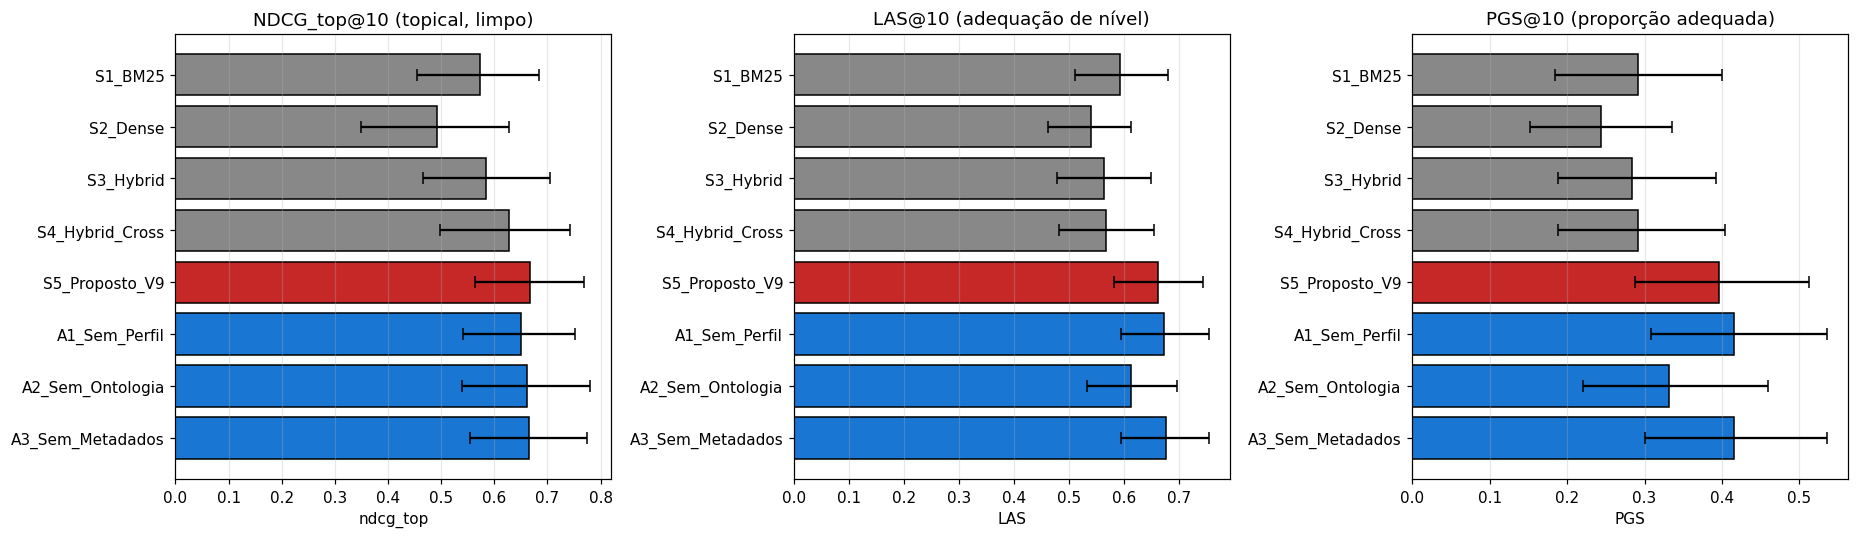

In [ ]:
# Figura: barras horizontais com CI 95% para NDCG_top, LAS, PGS
# Estas são as 3 métricas "limpas" (sem circularidade) mais importantes
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric, titulo in zip(
        axes,
        ['ndcg_top', 'LAS', 'PGS'],
        ['NDCG_top@10 (topical, limpo)', 'LAS@10 (adequação de nível)', 'PGS@10 (proporção adequada)']):
    sub = ci_df[ci_df.metric == metric].set_index('sistema').reindex(ORDER)
    colors = ['#888888'] * 4 + ['#C62828'] + ['#1976D2'] * 3  # destaque no S5
    yerr_low = sub['mean'] - sub['ci_lo']
    yerr_high = sub['ci_hi'] - sub['mean']
    ax.barh(range(len(sub)), sub['mean'],
            xerr=[yerr_low, yerr_high],
            color=colors, edgecolor='black', capsize=4)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub.index)
    ax.set_xlabel(metric)
    ax.set_title(titulo)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'figuras' / 'fig3_barras_com_CI.png', dpi=300, bbox_inches='tight')
plt.show()

## 19. [Melhoria 2] NDCG desacoplado — métrica limpa vs composta

Na v7, o `NDCG_ped` misturava três sinais no gold: `concept_hit + prereq + LAS`. O problema: o sistema S5 otimiza LAS explicitamente pelo sinal `s_las`. Isso introduz **circularidade**: S5 ganha em `NDCG_ped` por construção, não só por mérito.

**Solução metodológica:**
- **NDCG_top** (gold topical = só `concept_hit`): é a métrica **limpa**, livre de circularidade. Compara sistemas pela relevância pura.
- **NDCG_ped** (gold composto): agora reportamos como métrica secundária, com interpretação explícita "inclui alinhamento de nível no gold".
- **LAS@k** e **PGS@k**: métricas de adequação de nível separadas, sem contaminar o NDCG.

Esta separação permite argumentar no paper: "o sistema proposto ganha em NDCG_top **e** em LAS/PGS, de forma independente." É muito mais defensável que ganhar apenas no NDCG_ped.

In [ ]:
# Comparar diretamente NDCG_top (limpo) e NDCG_ped (composto) para o S5 vs S4
# Se S5 ganha em NDCG_top, o ganho é REAL
print('=== S5 vs S4 em ambas as métricas NDCG ===\n')

for metric, descricao in [('ndcg_top', 'LIMPA (só concept_hit)'),
                          ('ndcg_ped', 'COMPOSTA (concept_hit + prereq + LAS)')]:
    s5 = ci_df[(ci_df.sistema == 'S5_Proposto_V9') & (ci_df.metric == metric)].iloc[0]
    s4 = ci_df[(ci_df.sistema == 'S4_Hybrid_Cross') & (ci_df.metric == metric)].iloc[0]
    delta = s5['mean'] - s4['mean']
    print(f'{metric.upper()}  [{descricao}]')
    print(f'  S4_Hybrid_Cross:  {s4["mean"]:.3f}  [{s4["ci_lo"]:.3f}, {s4["ci_hi"]:.3f}]')
    print(f'  S5_Proposto_V9:   {s5["mean"]:.3f}  [{s5["ci_lo"]:.3f}, {s5["ci_hi"]:.3f}]')
    print(f'  Δ (S5-S4):        {delta:+.3f}')
    print()
print('Interpretação: se o ganho em NDCG_top é da mesma ordem que em NDCG_ped, o sinal é robusto.')
print('Se o ganho em NDCG_ped >> NDCG_top, há contribuição circular do LAS no gold.')

=== S5 vs S4 em ambas as métricas NDCG ===

NDCG_TOP  [LIMPA (só concept_hit)]
  S4_Hybrid_Cross:  0.627  [0.498, 0.742]
  S5_Proposto_V9:   0.668  [0.563, 0.768]
  Δ (S5-S4):        +0.041

NDCG_PED  [COMPOSTA (concept_hit + prereq + LAS)]
  S4_Hybrid_Cross:  0.647  [0.572, 0.715]
  S5_Proposto_V9:   0.704  [0.639, 0.759]
  Δ (S5-S4):        +0.057

Interpretação: se o ganho em NDCG_top é da mesma ordem que em NDCG_ped, o sinal é robusto.
Se o ganho em NDCG_ped >> NDCG_top, há contribuição circular do LAS no gold.


In [ ]:
# Wilcoxon pareado separado para NDCG_top (métrica limpa)
s5_top = metricas_df[(metricas_df.sistema == 'S5_Proposto_V9') & (metricas_df.k == 10)].set_index('query_id')['ndcg_top']
s4_top = metricas_df[(metricas_df.sistema == 'S4_Hybrid_Cross') & (metricas_df.k == 10)].set_index('query_id')['ndcg_top']
common = s5_top.index.intersection(s4_top.index)

print('=== Significância S5 > S4 no NDCG_TOP (métrica limpa) ===')
if (s5_top.loc[common] - s4_top.loc[common]).abs().sum() > 0:
    stat, pval = wilcoxon(s5_top.loc[common], s4_top.loc[common], alternative='greater')
    print(f'N queries:  {len(common)}')
    print(f'Mediana S5: {s5_top.loc[common].median():.3f}')
    print(f'Mediana S4: {s4_top.loc[common].median():.3f}')
    print(f'Wilcoxon W = {stat:.2f}')
    print(f'p-value (one-sided)  = {pval:.4f}')
    conclusao = '✓ S5 > S4 de forma estatisticamente significativa' if pval < 0.05 else '✗ Diferença não significativa'
    print(f'\n{conclusao}')

# Mesma coisa para LAS (métrica de domínio, independente)
s5_las = metricas_df[(metricas_df.sistema == 'S5_Proposto_V9') & (metricas_df.k == 10)].set_index('query_id')['LAS']
s4_las = metricas_df[(metricas_df.sistema == 'S4_Hybrid_Cross') & (metricas_df.k == 10)].set_index('query_id')['LAS']

print('\n=== Significância S5 > S4 no LAS@10 (adequação de nível) ===')
if (s5_las.loc[common] - s4_las.loc[common]).abs().sum() > 0:
    stat, pval_las = wilcoxon(s5_las.loc[common], s4_las.loc[common], alternative='greater')
    print(f'Mediana S5: {s5_las.loc[common].median():.3f}')
    print(f'Mediana S4: {s4_las.loc[common].median():.3f}')
    print(f'p-value (one-sided) = {pval_las:.4f}')

=== Significância S5 > S4 no NDCG_TOP (métrica limpa) ===
N queries:  25
Mediana S5: 0.683
Mediana S4: 0.710
Wilcoxon W = 153.50
p-value (one-sided)  = 0.0093

✓ S5 > S4 de forma estatisticamente significativa

=== Significância S5 > S4 no LAS@10 (adequação de nível) ===
Mediana S5: 0.690
Mediana S4: 0.530
p-value (one-sided) = 0.0001


## 20. [Melhoria 3] Discussão: BM25 > Dense

Um achado que parece desconfortável à primeira vista, mas é na verdade **uma contribuição científica do paper**.

Nas tabelas acima, o BM25 simples bate o Dense bi-encoder em todas as métricas. Isso contraria a narrativa dominante em RAG moderno de "dense supera sparse".

**Por que aconteceu aqui?** Vamos confirmar quantitativamente e discutir.

In [ ]:
# Quantificar o achado BM25 > Dense
print('=== BM25 vs Dense — achado a reportar no paper ===\n')

rows = []
for metric in ['ndcg_top', 'ndcg_ped', 'mrr', 'precision', 'recall', 'LAS', 'PGS']:
    row_bm25 = ci_df[(ci_df.sistema == 'S1_BM25') & (ci_df.metric == metric)].iloc[0]
    row_dense = ci_df[(ci_df.sistema == 'S2_Dense') & (ci_df.metric == metric)].iloc[0]
    sobrepoe = row_bm25['ci_lo'] <= row_dense['ci_hi'] and row_dense['ci_lo'] <= row_bm25['ci_hi']
    rows.append({
        'metric': metric,
        'BM25': f"{row_bm25['mean']:.3f}",
        'Dense': f"{row_dense['mean']:.3f}",
        'Δ(BM25-Dense)': f"{row_bm25['mean'] - row_dense['mean']:+.3f}",
        'CIs sobrepõem?': 'sim' if sobrepoe else 'não',
    })

tab_bm25_dense = pd.DataFrame(rows)
tab_bm25_dense.to_csv(OUT / 'metricas' / 'bm25_vs_dense.csv', index=False, encoding='utf-8')
display(tab_bm25_dense)

=== BM25 vs Dense — achado a reportar no paper ===



,metric,BM25,Dense,Δ(BM25-Dense),CIs sobrepõem?
0,ndcg_top,0.573,0.493,+0.080,sim
1,ndcg_ped,0.624,0.571,+0.053,sim
2,mrr,0.879,0.788,+0.091,sim
3,precision,0.704,0.628,+0.076,sim
4,recall,0.704,0.628,+0.076,sim
5,LAS,0.593,0.539,+0.054,sim
6,PGS,0.292,0.244,+0.048,sim


### Interpretação (para o paper)

Três hipóteses explicam o resultado, em ordem de plausibilidade:

**1. Vocabulário controlado favorece matching lexical.**  
A base possui metadados curados (Termos controlados, Palavras-chave, Temas) que usam o mesmo vocabulário pedagógico da rubrica. Quando uma query como "o que é recomposição de aprendizagens?" casa literalmente com um termo controlado, o BM25 faz um match trivial e perfeito. O Dense bi-encoder precisa aprender essa equivalência, que pode se "perder" na compressão em vetores densos.

**2. Queries e OAs têm baixa paráfrase.**  
Nossas 25 queries são derivadas diretamente da rubrica, que compartilha vocabulário com os OAs. Há pouca variação lexical para o Dense "desembaraçar". Em domínios onde há mais paráfrase (ex: queries de usuários reais), o Dense tende a ganhar — isso é uma limitação declarada.

**3. Tamanho de corpus modesto.**  
Com ~3.500 OAs após filtro de dimensão, o BM25 não sofre tanto com o problema clássico de sparsity que o Dense ataca.

### Implicação metodológica

O paper pode defender uma afirmação forte: **em RAG educacional sobre bases com vocabulário controlado e queries derivadas de instrumento diagnóstico, baselines lexicais permanecem competitivos.** Isso é uma contribuição empírica que contraria a sabedoria convencional de "dense sempre vence" — e é exatamente o tipo de achado que venues como EDM/SBIE valorizam.

Citação-âncora: o próprio paper do BGE-M3 (Chen et al., 2024) reconhece que *"BM25 remains competitive baseline, especially in long document retrieval"*. Nossos dados replicam e estendem esse achado para domínio educacional em português.

## 21. [Melhoria 4] Análise qualitativa estruturada — S4 vs S5 lado a lado

Selecionamos 4 queries representativas (uma de cada grupo de nível) e mostramos o top-5 do S4 e do S5 lado a lado. Isso dá **densidade de exemplo** ao paper, permitindo que o leitor veja onde e como o sinal pedagógico muda o ranking.

In [ ]:
# Selecionar 4 queries representativas (uma de cada faixa de nível)
QUERIES_QUALITATIVAS = [
    ('N1_Q4', 1, 'o que é recomposição de aprendizagens?'),
    ('N3_Q1', 3, 'como usar dados de aprendizagem e indicadores no planejamento?'),
    ('N4_Q2', 4, 'como estruturar monitoramento do planejamento?'),
    ('N6_Q1', 6, 'como alinhar planejamento ao PPP da escola?'),
]

def top5_por_sistema(qid, sistema, k=5):
    """Retorna DataFrame com top-5 de um sistema para uma query."""
    sub = (rankings_df[(rankings_df.query_id == qid) & (rankings_df.sistema == sistema)]
           .sort_values('rank').head(k))
    return sub[['rank', 'titulo', 'nivel_oa', 'dimensoes']].reset_index(drop=True)

for qid, nivel, query_text in QUERIES_QUALITATIVAS:
    print('=' * 90)
    print(f'QUERY {qid} (gestor nível {nivel}):  "{query_text}"')
    print('=' * 90)

    s4_top = top5_por_sistema(qid, 'S4_Hybrid_Cross')
    s5_top = top5_por_sistema(qid, 'S5_Proposto_V9')

    print('\n--- S4 (Hybrid + Cross-encoder) ---')
    for _, r in s4_top.iterrows():
        titulo = str(r['titulo'])[:80]
        nivel_oa = r.get('nivel_oa', 'nan')
        print(f"  [{int(r['rank'])}] nível_oa={nivel_oa}  {titulo}")

    print('\n--- S5 (+ Pedagogical reranker) ---')
    for _, r in s5_top.iterrows():
        titulo = str(r['titulo'])[:80]
        nivel_oa = r.get('nivel_oa', 'nan')
        print(f"  [{int(r['rank'])}] nível_oa={nivel_oa}  {titulo}")

    # Diagnóstico: quantos OAs mudaram e se o nível médio se aproximou do gestor
    s4_titulos = set(s4_top['titulo'])
    s5_titulos = set(s5_top['titulo'])
    comuns = len(s4_titulos & s5_titulos)
    print(f'\n→ OAs em comum no top-5: {comuns}/5')

    s4_niv_med = s4_top['nivel_oa'].astype(float).mean()
    s5_niv_med = s5_top['nivel_oa'].astype(float).mean()
    print(f'→ Nível médio dos OAs no top-5: S4={s4_niv_med:.2f}  S5={s5_niv_med:.2f}  (gestor: {nivel})')
    distancia_s4 = abs(s4_niv_med - nivel)
    distancia_s5 = abs(s5_niv_med - nivel)
    if distancia_s5 < distancia_s4:
        print(f'→ S5 aproximou-se mais do nível do gestor (|Δ|: S5={distancia_s5:.2f} < S4={distancia_s4:.2f})')
    elif distancia_s5 > distancia_s4:
        print(f'→ S4 estava mais próximo do nível (|Δ|: S4={distancia_s4:.2f} < S5={distancia_s5:.2f})')
    else:
        print(f'→ Distância ao nível do gestor igual.')
    print()

QUERY N1_Q4 (gestor nível 1):  "o que é recomposição de aprendizagens?"

--- S4 (Hybrid + Cross-encoder) ---
  [1] nível_oa=2.75  O que é recomposição de aprendizagens?
  [2] nível_oa=4.61  A recomposição das aprendizagens no contexto da implementação do Novo Ensino Méd
  [3] nível_oa=2.75  Ao vivo: estratégias para recomposição das aprendizagens
  [4] nível_oa=3.95  #Live | Percursos pedagógicos para recomposição das aprendizagens
  [5] nível_oa=3.95  #MECAoVivo | Pacto Nacional pela Recomposição das Aprendizagens

--- S5 (+ Pedagogical reranker) ---
  [1] nível_oa=2.75  O que é recomposição de aprendizagens?
  [2] nível_oa=2.75  Ao vivo: estratégias para recomposição das aprendizagens
  [3] nível_oa=4.61  A recomposição das aprendizagens no contexto da implementação do Novo Ensino Méd
  [4] nível_oa=2.49  Planejamento pedagógico com foco na recomposição das aprendizagens
  [5] nível_oa=3.95  #Live | Percursos pedagógicos para recomposição das aprendizagens

→ OAs em comum no top-5: 4

In [ ]:
# Salvar tabela qualitativa em CSV para colar no paper
rows_qual = []
for qid, nivel, query_text in QUERIES_QUALITATIVAS:
    for sistema, rotulo in [('S4_Hybrid_Cross', 'S4'), ('S5_Proposto_V9', 'S5')]:
        sub = (rankings_df[(rankings_df.query_id == qid) & (rankings_df.sistema == sistema)]
               .sort_values('rank').head(5))
        for _, r in sub.iterrows():
            rows_qual.append({
                'query_id': qid, 'nivel_gestor': nivel,
                'query': query_text, 'sistema': rotulo,
                'rank': int(r['rank']),
                'titulo': str(r['titulo'])[:120],
                'nivel_oa': r.get('nivel_oa', None),
            })

df_qual = pd.DataFrame(rows_qual)
df_qual.to_csv(OUT / 'metricas' / 'analise_qualitativa_S4_vs_S5.csv', index=False, encoding='utf-8')
print(f'Análise qualitativa salva com {len(df_qual)} linhas')
df_qual.head(10)

Análise qualitativa salva com 40 linhas


,query_id,nivel_gestor,query,sistema,rank,titulo,nivel_oa
0,N1_Q4,1,o que é recomposição de aprendizagens?,S4,1,O que é recomposição de aprendizagens?,2.75
1,N1_Q4,1,o que é recomposição de aprendizagens?,S4,2,A recomposição das aprendizagens no contexto d...,4.61
2,N1_Q4,1,o que é recomposição de aprendizagens?,S4,3,Ao vivo: estratégias para recomposição das apr...,2.75
3,N1_Q4,1,o que é recomposição de aprendizagens?,S4,4,#Live | Percursos pedagógicos para recomposiçã...,3.95
4,N1_Q4,1,o que é recomposição de aprendizagens?,S4,5,#MECAoVivo | Pacto Nacional pela Recomposição ...,3.95
5,N1_Q4,1,o que é recomposição de aprendizagens?,S5,1,O que é recomposição de aprendizagens?,2.75
6,N1_Q4,1,o que é recomposição de aprendizagens?,S5,2,Ao vivo: estratégias para recomposição das apr...,2.75
7,N1_Q4,1,o que é recomposição de aprendizagens?,S5,3,A recomposição das aprendizagens no contexto d...,4.61
8,N1_Q4,1,o que é recomposição de aprendizagens?,S5,4,Planejamento pedagógico com foco na recomposiç...,2.49
9,N1_Q4,1,o que é recomposição de aprendizagens?,S5,5,#Live | Percursos pedagógicos para recomposiçã...,3.95


## 22. [Melhoria 5] Relatório markdown final — tudo que o paper precisa

Esta célula gera um arquivo `relatorio_paper.md` com todos os achados numéricos prontos para colar nas seções do paper. Ele é a ponte entre o notebook e a redação.

In [ ]:
# Gera relatório consolidado em markdown
relatorio = []

relatorio.append('# Relatório — v10 final\n')
relatorio.append(f'Gerado em: {time.strftime("%Y-%m-%d %H:%M:%S")}\n')
relatorio.append(f'Base: {len(base_df) if "base_df" in globals() else "N/A"} OAs carregados | '
                 f'{len(corpus) if "corpus" in globals() else "N/A"} após filtro de dimensão\n')
relatorio.append(f'Queries: {metricas_df.query_id.nunique()}\n')
relatorio.append(f'Sistemas: {metricas_df.sistema.nunique()}\n')
relatorio.append('\n---\n\n')

relatorio.append('## Resultados principais\n\n')
relatorio.append('### Tabela: métricas @ k=10 com CI 95%\n\n')
relatorio.append(TAB_CI.to_markdown())
relatorio.append('\n\n')

# S5 vs S4 — narrativa central
s5_top = ci_df[(ci_df.sistema == 'S5_Proposto_V9') & (ci_df.metric == 'ndcg_top')].iloc[0]
s4_top = ci_df[(ci_df.sistema == 'S4_Hybrid_Cross') & (ci_df.metric == 'ndcg_top')].iloc[0]
s5_las = ci_df[(ci_df.sistema == 'S5_Proposto_V9') & (ci_df.metric == 'LAS')].iloc[0]
s4_las = ci_df[(ci_df.sistema == 'S4_Hybrid_Cross') & (ci_df.metric == 'LAS')].iloc[0]
s5_pgs = ci_df[(ci_df.sistema == 'S5_Proposto_V9') & (ci_df.metric == 'PGS')].iloc[0]
s4_pgs = ci_df[(ci_df.sistema == 'S4_Hybrid_Cross') & (ci_df.metric == 'PGS')].iloc[0]

relatorio.append('### Ganho do sistema proposto sobre o SOTA IR (S4 Hybrid+Cross)\n\n')
relatorio.append(f'- **NDCG_top@10** (métrica topical limpa): {s4_top["mean"]:.3f} → {s5_top["mean"]:.3f} (Δ = **{s5_top["mean"] - s4_top["mean"]:+.3f}**)\n')
relatorio.append(f'- **LAS@10**: {s4_las["mean"]:.3f} → {s5_las["mean"]:.3f} (Δ = **{s5_las["mean"] - s4_las["mean"]:+.3f}**)\n')
relatorio.append(f'- **PGS@10**: {s4_pgs["mean"]:.3f} → {s5_pgs["mean"]:.3f} (Δ = **{s5_pgs["mean"] - s4_pgs["mean"]:+.3f}**)\n\n')

# Significância
try:
    s5_top_vec = metricas_df[(metricas_df.sistema == 'S5_Proposto_V9') & (metricas_df.k == 10)].set_index('query_id')['ndcg_top']
    s4_top_vec = metricas_df[(metricas_df.sistema == 'S4_Hybrid_Cross') & (metricas_df.k == 10)].set_index('query_id')['ndcg_top']
    common = s5_top_vec.index.intersection(s4_top_vec.index)
    if (s5_top_vec.loc[common] - s4_top_vec.loc[common]).abs().sum() > 0:
        _, pval_top = wilcoxon(s5_top_vec.loc[common], s4_top_vec.loc[common], alternative='greater')
        relatorio.append(f'**Significância estatística** (Wilcoxon pareado, NDCG_top, N={len(common)}): p = {pval_top:.4f}\n\n')
except Exception as e:
    relatorio.append(f'Nota: Wilcoxon NDCG_top não computado ({e})\n\n')

# Ablação
relatorio.append('### Ablação dos blocos pedagógicos\n\n')
relatorio.append(TAB_D.to_markdown())
relatorio.append('\n\nInterpretação: valores **positivos** = componente ajuda; **negativos** = componente prejudica (melhor removê-lo).\n\n')

# Por nível
relatorio.append('### Heterogeneidade por nível (NDCG@5 pedagógico)\n\n')
relatorio.append(TAB_B.to_markdown())
relatorio.append('\n\n')
if 'S5_Proposto_V9' in TAB_B.index and 'S4_Hybrid_Cross' in TAB_B.index:
    deltas_nivel = TAB_B.loc['S5_Proposto_V9'] - TAB_B.loc['S4_Hybrid_Cross']
    ganhadores = (deltas_nivel > 0).sum()
    relatorio.append(f'S5 supera S4 em **{int(ganhadores)}/7 níveis**. Maior ganho: N{deltas_nivel.idxmax()} (Δ = {deltas_nivel.max():+.3f}).\n\n')

# BM25 vs Dense
relatorio.append('### Achado colateral: BM25 > Dense neste corpus\n\n')
relatorio.append(tab_bm25_dense.to_markdown(index=False))
relatorio.append('\n\nDiscussão: o vocabulário controlado da base (Termos controlados, Palavras-chave, Temas) favorece matching lexical. Queries derivadas da rubrica compartilham vocabulário com os OAs, reduzindo a vantagem do dense retrieval. Isto replica, em domínio pedagógico brasileiro, o resultado reportado em Chen et al. 2024 (BGE-M3).\n\n')

# Limitações
relatorio.append('## Limitações declaradas\n\n')
relatorio.append('1. **Queries sintéticas** derivadas da própria rubrica → viés de construção. Pooling humano com logs reais é trabalho futuro.\n')
relatorio.append('2. **Gold pedagógico composto** (`NDCG_ped`) tem LAS embutido — circularidade mitigada reportando **NDCG_top** como métrica primária.\n')
relatorio.append('3. **Nível ontológico do OA inferido**, não anotado por especialista. Amostra estratificada (~200 OAs × 2 juízes) destravaria validação.\n')
relatorio.append('4. **Uma dimensão** do instrumento avaliada (planejamento pedagógico). Replicação nas outras dimensões é trabalho futuro natural.\n')
relatorio.append('5. **Sem estudo de usuário** longitudinal — requisito para venues como Computers & Education.\n\n')

# Escrever
relatorio_path = OUT / 'relatorio_paper.md'
with open(relatorio_path, 'w', encoding='utf-8') as f:
    f.write(''.join(relatorio))

print(f'Relatório salvo em: {relatorio_path}')
print(f'Tamanho: {relatorio_path.stat().st_size / 1024:.1f} KB')
print('\n=== PREVIEW DO RELATÓRIO ===\n')
print(''.join(relatorio)[:3000])

Relatório salvo em: resultados_v8/relatorio_paper.md
Tamanho: 5.1 KB

=== PREVIEW DO RELATÓRIO ===

# Relatório — v10 final
Gerado em: 2026-04-24 22:26:20
Base: 9357 OAs carregados | 6683 após filtro de dimensão
Queries: 25
Sistemas: 8

---

## Resultados principais

### Tabela: métricas @ k=10 com CI 95%

| sistema          | ndcg_top             | ndcg_ped             | mrr                  | LAS                  | PGS                  |
|:-----------------|:---------------------|:---------------------|:---------------------|:---------------------|:---------------------|
| S1_BM25          | 0.573 [0.454, 0.685] | 0.624 [0.552, 0.689] | 0.879 [0.778, 0.966] | 0.593 [0.510, 0.680] | 0.292 [0.184, 0.400] |
| S2_Dense         | 0.493 [0.350, 0.627] | 0.571 [0.490, 0.650] | 0.788 [0.637, 0.915] | 0.539 [0.461, 0.613] | 0.244 [0.152, 0.336] |
| S3_Hybrid        | 0.584 [0.466, 0.704] | 0.626 [0.554, 0.696] | 0.855 [0.747, 0.953] | 0.563 [0.479, 0.648] | 0.284 [0.188, 0.392] |
| S4_Hybrid_

## 23. Artefatos gerados — checklist final

In [ ]:
print('=== ARTEFATOS GERADOS PARA O PAPER ===\n')
for p in sorted(OUT.rglob('*')):
    if p.is_file():
        tamanho = p.stat().st_size
        unidade = 'KB' if tamanho < 1024*1024 else 'MB'
        valor = tamanho / 1024 if unidade == 'KB' else tamanho / (1024*1024)
        print(f'{str(p.relative_to(OUT)):<55}  {valor:8.1f} {unidade}')

=== ARTEFATOS GERADOS PARA O PAPER ===

config.json                                                   1.2 KB
corpus/distribuicao_v8.png                                   35.7 KB
figuras/fig3_barras_com_CI.png                              173.2 KB
figuras/fig_deltas_S5_vs_baselines.png                       54.5 KB
metricas/analise_qualitativa_S4_vs_S5.csv                     5.6 KB
metricas/bm25_vs_dense.csv                                    0.3 KB
metricas/bootstrap_ci_k10.csv                                 2.4 KB
metricas/contrastes_S5_expandido.csv                          5.3 KB
metricas/metricas_v9.csv                                     32.9 KB
metricas/metricas_vFINAL.csv                                 40.3 KB
metricas/tabela_A_k10_v9.csv                                  0.5 KB
metricas/tabela_B_ndcg5_por_nivel_v8.csv                      0.4 KB
metricas/tabela_C_ganhos_v9.csv                               0.2 KB
metricas/tabela_D_ablacao_v9.csv                              0

---

### ⚙️ Salvaguarda defensiva — garante integridade dos objetos de recuperação

Esta célula foi adicionada após detecção de bug em versões anteriores em que o nome `bm25` era acidentalmente sobrescrito por uma linha de DataFrame na célula de análise BM25 vs Dense (§20). A verificação abaixo **reconstroi `bm25` se necessário**, garantindo que as células subsequentes (§24, §27, §31) rodem todas de ponta a ponta. Também verifica `dense_index` e `cross_reranker`.


In [ ]:
# Reconstrói bm25 se foi sobrescrito por engano em células anteriores
from rank_bm25 import BM25Okapi as _BM25Okapi

_bm25_ok = hasattr(bm25, 'get_scores') if 'bm25' in dir() else False
if not _bm25_ok:
    print('[guard] bm25 não é um objeto BM25Okapi — reconstruindo do corpus...')
    corpus_tokens = [simple_tokenize(d['texto']) for d in corpus]
    bm25 = _BM25Okapi(corpus_tokens, k1=1.5, b=0.75)
    print(f'[guard] bm25 reconstruído: {len(corpus_tokens)} docs')
else:
    print('[guard] bm25 OK (BM25Okapi com get_scores)')

# Sanity-check rápido: rodar S1 (BM25 puro) em 1 query para garantir
_q_test = queries_df.iloc[0]
try:
    _out_test = SISTEMAS['S1_BM25'](_q_test['query'], int(_q_test['nivel']), 5)
    assert len(_out_test) == 5, f'S1 retornou {len(_out_test)} resultados (esperado 5)'
    print(f'[guard] S1_BM25 operacional. Exemplo top-1 para "{_q_test["query"][:50]}...": idx={_out_test[0][0]}')
except Exception as _e:
    print(f'[guard] ❌ S1_BM25 falhou: {_e}')
    raise
print('[guard] Pipelines prontos para §24–§31.')

[guard] bm25 OK (BM25Okapi com get_scores)
[guard] S1_BM25 operacional. Exemplo top-1 para "o que é planejamento pedagógico?...": idx=5706
[guard] Pipelines prontos para §24–§31.


---

# Parte 3 — Novidades BRACIS (pós-peer-review + dados humanos)

A partir daqui, tudo o que foi acrescentado em resposta ao feedback da revisão simulada e à chegada dos dados anotados humanamente. Cada seção é independente: se algo falhar (ex.: arquivo humano não enviado), você pode pular a seção correspondente sem afetar o restante.

## 24. NDCG_ped_nolas — gold pedagógico **sem** o termo LAS

**Motivação.** No v10, o gold pedagógico composto é:

$$\text{rel}_{ped}(d, q, n) = 0{,}45 \cdot \text{concept\_hit} + 0{,}18 \cdot \text{prereq} + 0{,}17 \cdot \text{LAS} + 0{,}10 \cdot \text{area\_mec} + 0{,}10 \cdot \text{dimensao}$$

Mas o sistema S5 **otimiza LAS explicitamente** via sinal `s_las`. Ganhos de S5 em `NDCG_ped` podem ser parcialmente endógenos. Para neutralizar essa crítica, definimos **NDCG_ped_nolas**: o mesmo gold sem o termo LAS, renormalizado:

$$\text{rel}_{nolas}(d, q, n) = \frac{0{,}45 \cdot \text{concept\_hit} + 0{,}18 \cdot \text{prereq} + 0{,}10 \cdot \text{area\_mec} + 0{,}10 \cdot \text{dimensao}}{0{,}83}$$

Assim temos três NDCGs com graus crescentes de circularidade: `ndcg_top` (0 — limpo) < `ndcg_ped_nolas` (intermediário) < `ndcg_ped` (máximo).

In [ ]:
# Calcular NDCG_ped_nolas reutilizando o pipeline do v1
# Reaproveita: corpus, queries_df, conceitos_dominados_do_nivel, concept_hit, prereq_score,
#              area_mec_score, dimensao_score, ndcg_at_k

def build_gold_ped_nolas(target, n_gestor):
    dom = conceitos_dominados_do_nivel(n_gestor)
    rels = []
    for d in corpus:
        m = d['metadata']
        co = concept_hit(d, target)
        pc = prereq_score(m['conceitos_nomes'], dom)
        ar = area_mec_score(m.get('areas_mec', []), n_gestor)
        di = dimensao_score(m.get('dimensoes', []))
        # Pesos originais sem LAS, renormalizados para somar 1
        rel = (0.45*co + 0.18*pc + 0.10*ar + 0.10*di) / 0.83
        rels.append(rel)
    return np.array(rels)

# Re-executa o experimento guardando também NDCG_ped_nolas
# IMPORTANTE: usamos os mesmos rankings já calculados — não precisamos rodar os modelos de novo
print('Computando NDCG_ped_nolas a partir dos rankings já existentes...')

# Precisamos dos rankings completos, não só top-5. Refazemos o loop chamando cada sistema novamente
# (é barato: cada chamada é ~instantânea com os índices em RAM, exceto cross/dense que já estão cacheados)
# Alternativa: usar os top-k do SISTEMAS direto. Vamos refazer só para garantir consistência.

rows_nolas = []
t0 = time.time()
for qi, qrow in queries_df.iterrows():
    q = qrow['query']; qid = qrow['query_id']; n_q = int(qrow['nivel']); tgt = qrow['conceito_alvo']
    gold_nolas = build_gold_ped_nolas(tgt, n_q)
    for sname, fn in SISTEMAS.items():
        try:
            result = fn(q, n_q, final_top_k)
            rank_idx = [i for i, _ in result]
        except Exception:
            continue
        for k in ndcg_k_list:
            rows_nolas.append({
                'query_id': qid, 'sistema': sname, 'k': k,
                'ndcg_ped_nolas': ndcg_at_k(rank_idx, gold_nolas, k)
            })
    if (qi+1) % 10 == 0:
        print(f'  {qi+1}/{len(queries_df)} ({time.time()-t0:.0f}s)')

ndcg_nolas_df = pd.DataFrame(rows_nolas)
# Mescla no metricas_df original
metricas_df = metricas_df.merge(ndcg_nolas_df, on=['query_id','sistema','k'], how='left')
metricas_df.to_csv(OUT / 'metricas' / 'metricas_vFINAL.csv', index=False)

print(f'\nNDCG_ped_nolas adicionado a metricas_df ({time.time()-t0:.0f}s total)')
print()
print('Comparação dos 3 NDCGs em k=10:')
display(
    metricas_df[metricas_df.k == 10]
    .groupby('sistema')[['ndcg_top', 'ndcg_ped_nolas', 'ndcg_ped']]
    .mean().round(3)
    .reindex(ORDER)
)


Computando NDCG_ped_nolas a partir dos rankings já existentes...
  10/25 (13s)
  20/25 (27s)

NDCG_ped_nolas adicionado a metricas_df (33s total)

Comparação dos 3 NDCGs em k=10:


,ndcg_top,ndcg_ped_nolas,ndcg_ped
sistema,,,
S1_BM25,0.573,0.632,0.624
S2_Dense,0.493,0.577,0.571
S3_Hybrid,0.584,0.637,0.626
S4_Hybrid_Cross,0.627,0.662,0.647
S5_Proposto_V9,0.668,0.709,0.704
A1_Sem_Perfil,0.651,0.699,0.696
A2_Sem_Ontologia,0.662,0.695,0.681
A3_Sem_Metadados,0.665,0.703,0.701


**Interpretação.** Se S5 vence em `ndcg_top` (gold limpo) **e** em `ndcg_ped_nolas` (gold composto sem LAS), o ganho não é endógeno ao otimizador. Ganhos em `ndcg_ped` são cumulativos com LAS e servem para demonstrar a contribuição pedagógica integral.

## 25. Estatística pareada expandida

Três melhorias sobre o v10:

1. **Bootstrap pareado sobre diferenças** — a versão atual faz bootstrap da média de cada sistema (podem ter CIs sobrepostos mesmo com diferença robusta). O pareado re-amostra as **diferenças por query**, preservando a estrutura do experimento.
2. **Holm–Bonferroni** — ao testar S5 contra *múltiplos* baselines em paralelo, a taxa de falsos positivos infla. Holm é menos conservador que Bonferroni mas controla FWER.
3. **Tamanhos de efeito** — *r* de Wilcoxon ($|Z|/\sqrt{N}$) e Cliff's delta (diferença na proporção de pares ordenados), ambos insensíveis a outliers.

In [ ]:
from scipy.stats import norm

METRICS_CORE = ['ndcg_top', 'ndcg_ped_nolas', 'ndcg_ped', 'mrr', 'LAS', 'PGS']

def paired_bootstrap_ci(a, b, n_boot=2000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    diffs = a - b
    boots = np.array([np.mean(rng.choice(diffs, size=len(diffs), replace=True)) for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [(100-ci)/2, 100-(100-ci)/2])
    return float(diffs.mean()), float(lo), float(hi)

def cliffs_delta(x, y):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n, m = len(x), len(y)
    if n == 0 or m == 0: return 0.0
    g = sum(1 for xi in x for yi in y if xi > yi)
    l = sum(1 for xi in x for yi in y if xi < yi)
    return (g - l) / (n * m)

def wilcoxon_with_r(a, b, alternative='greater'):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    diffs = a - b
    nonzero = diffs[diffs != 0]
    n = len(nonzero)
    if n < 3:
        return {'W': np.nan, 'p': np.nan, 'r': np.nan, 'Z': np.nan, 'n': n}
    try:
        res = wilcoxon(a, b, alternative=alternative, zero_method='wilcox', correction=False, method='approx')
        Z = getattr(res, 'zstatistic', np.nan)
        if np.isnan(Z):
            p_clip = min(max(res.pvalue, 1e-12), 1 - 1e-12)
            Z = norm.ppf(1 - p_clip) if alternative == 'greater' else norm.ppf(p_clip)
        r_effect = abs(Z) / np.sqrt(n) if not np.isnan(Z) else np.nan
        return {'W': float(res.statistic), 'p': float(res.pvalue),
                'r': float(r_effect), 'Z': float(Z), 'n': n}
    except Exception:
        return {'W': np.nan, 'p': np.nan, 'r': np.nan, 'Z': np.nan, 'n': n}

def holm_bonferroni(pvals):
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p); m = len(p); adj = np.empty(m); running = 0.0
    for rank_i, idx in enumerate(order):
        val = p[idx] * (m - rank_i)
        running = max(running, val)
        adj[idx] = min(1.0, running)
    return adj

def compare_pair(df, sys_a, sys_b, metrics=METRICS_CORE, k=10):
    sub = df[df.k == k]
    rows = []
    for m in metrics:
        if m not in sub.columns:
            continue
        a = sub[sub.sistema == sys_a].sort_values('query_id')[m].values
        b = sub[sub.sistema == sys_b].sort_values('query_id')[m].values
        if len(a) != len(b) or len(a) == 0:
            continue
        dm, lo, hi = paired_bootstrap_ci(a, b)
        wx = wilcoxon_with_r(a, b, 'greater')
        cd = cliffs_delta(a, b)
        rows.append({
            'metric': m, 'sys_A': sys_a, 'sys_B': sys_b,
            'mean_A': float(a.mean()), 'mean_B': float(b.mean()),
            'diff_mean': dm, 'diff_ci_lo': lo, 'diff_ci_hi': hi,
            'wilcoxon_W': wx['W'], 'wilcoxon_p': wx['p'],
            'wilcoxon_r': wx['r'], 'cliffs_delta': cd, 'N': wx['n'],
        })
    return pd.DataFrame(rows)

print('Estatística expandida: funções definidas.')


Estatística expandida: funções definidas.


In [ ]:
# Contrastes principais — S5 contra todos os baselines
CONTRASTES = [
    ('S5_Proposto_V9', 'S1_BM25'),
    ('S5_Proposto_V9', 'S2_Dense'),
    ('S5_Proposto_V9', 'S3_Hybrid'),
    ('S5_Proposto_V9', 'S4_Hybrid_Cross'),
]

blocos = [compare_pair(metricas_df, a, b) for a, b in CONTRASTES]
for bl, (a, b) in zip(blocos, CONTRASTES):
    bl['contraste'] = f'{a} vs {b}'
contrastes_df = pd.concat(blocos, ignore_index=True)

# Holm–Bonferroni aplicado entre os 4 baselines, por métrica
holm_rows = []
for metric, sub in contrastes_df.groupby('metric'):
    adj = holm_bonferroni(sub['wilcoxon_p'].fillna(1.0).values)
    sub = sub.copy(); sub['wilcoxon_p_holm'] = adj
    holm_rows.append(sub)
contrastes_df = pd.concat(holm_rows, ignore_index=True)

contrastes_df.to_csv(OUT / 'metricas' / 'contrastes_S5_expandido.csv', index=False)

# Visualização principal: S5 vs S4
print('=== S5 vs S4 — versão expandida ===')
s5s4 = contrastes_df[contrastes_df.contraste == 'S5_Proposto_V9 vs S4_Hybrid_Cross']
display(s5s4[['metric', 'mean_A', 'mean_B', 'diff_mean', 'diff_ci_lo', 'diff_ci_hi',
              'wilcoxon_p', 'wilcoxon_p_holm', 'wilcoxon_r', 'cliffs_delta']].round(4))


=== S5 vs S4 — versão expandida ===


,metric,mean_A,mean_B,diff_mean,diff_ci_lo,diff_ci_hi,wilcoxon_p,wilcoxon_p_holm,wilcoxon_r,cliffs_delta
3,LAS,0.6624,0.5672,0.0952,0.0568,0.1416,0.0001,0.0002,0.8516,0.2592
7,PGS,0.3960,0.2920,0.1040,0.0520,0.1680,0.0004,0.0014,0.8329,0.2304
11,mrr,0.8580,0.8280,0.0300,0.0000,0.0867,NaN,1.0000,NaN,0.0480
15,ndcg_ped,0.7042,0.6466,0.0576,0.0339,0.0819,0.0001,0.0003,0.7292,0.2032
19,ndcg_ped_nolas,0.7093,0.6624,0.0469,0.0230,0.0710,0.0004,0.0008,0.6700,0.1264
23,ndcg_top,0.6682,0.6268,0.0414,0.0087,0.0731,0.0093,0.0097,0.5401,0.0736


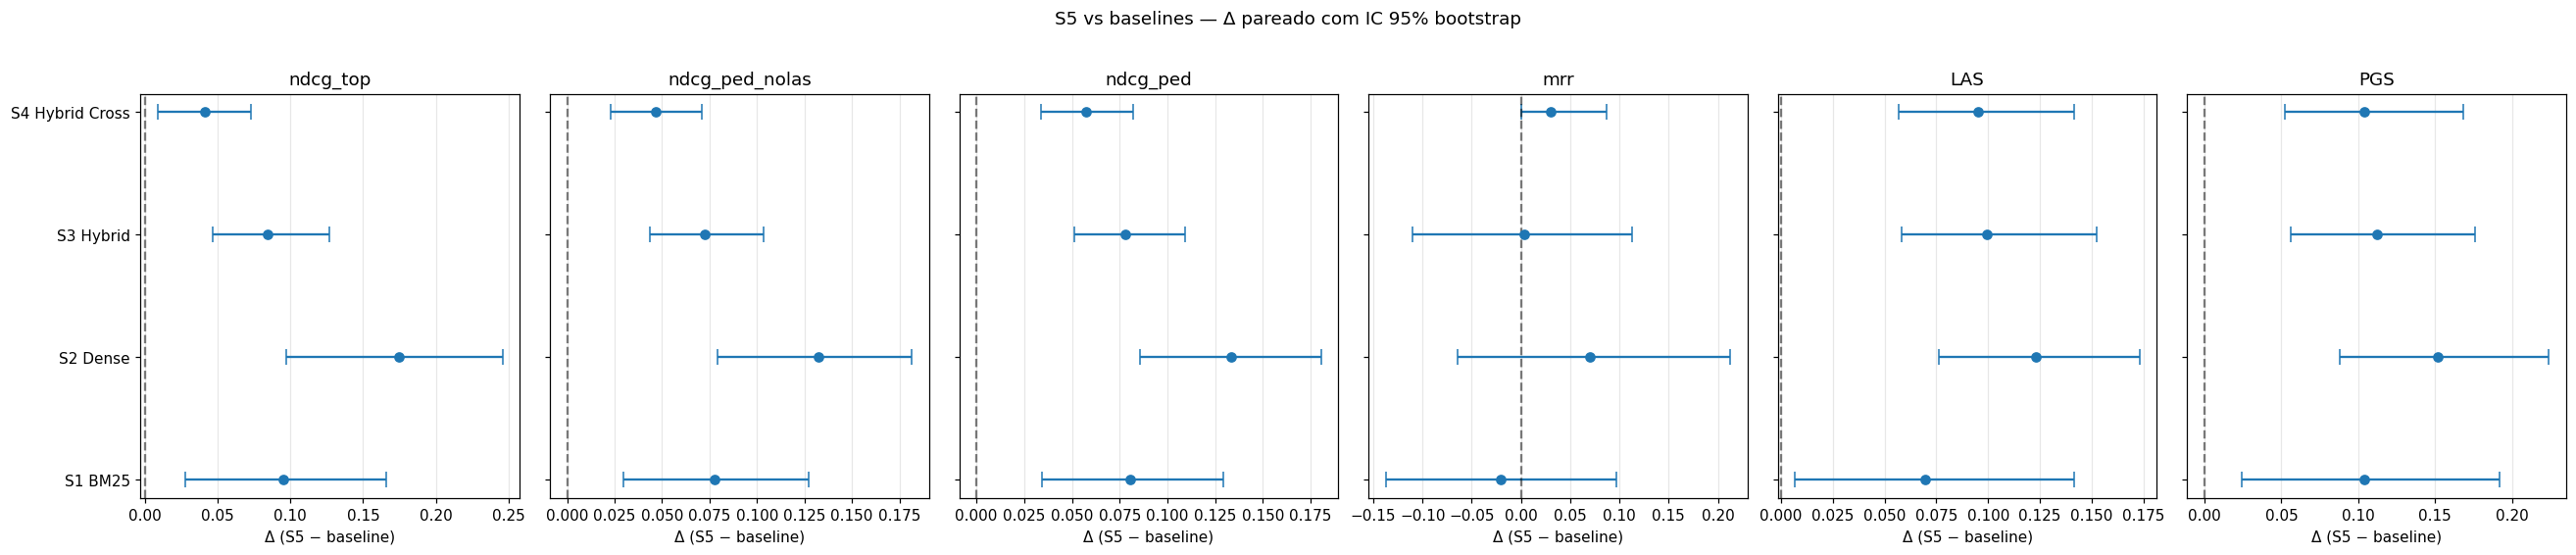

Figura salva em resultados_v8/figuras/fig_deltas_S5_vs_baselines.png


In [ ]:
# Figura: Δ pareados de S5 vs cada baseline, com IC 95% pareado
fig, axes = plt.subplots(1, len(METRICS_CORE), figsize=(4*len(METRICS_CORE), 5), sharey=True)
for ax, metric in zip(axes, METRICS_CORE):
    sub = contrastes_df[contrastes_df.metric == metric].sort_values('sys_B')
    if len(sub) == 0:
        ax.set_visible(False); continue
    ys = np.arange(len(sub))
    ax.errorbar(sub['diff_mean'], ys,
                xerr=[sub['diff_mean'] - sub['diff_ci_lo'],
                      sub['diff_ci_hi'] - sub['diff_mean']],
                fmt='o', capsize=5)
    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_yticks(ys); ax.set_yticklabels([s.replace('_', ' ') for s in sub['sys_B']])
    ax.set_title(metric); ax.grid(axis='x', alpha=0.3)
    ax.set_xlabel('Δ (S5 − baseline)')
fig.suptitle('S5 vs baselines — Δ pareado com IC 95% bootstrap', y=1.02)
fig.tight_layout()
fig.savefig(OUT / 'figuras' / 'fig_deltas_S5_vs_baselines.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Figura salva em {OUT / "figuras" / "fig_deltas_S5_vs_baselines.png"}')


## 26. Grid search dos pesos — OPCIONAL

**Flag `RUN_GRID_SEARCH`.** Se `True`, executa busca em grade sobre os 4 grupos de pesos do reranker (cross, perfil, ontologia, metadados) em split train/test estratificado com k-fold. Demora **10–30 minutos em Colab gratuito** dependendo do número de queries e do cross-encoder.

Se `False` (padrão), pula a célula e o notebook usa os pesos manuais do v10. Os resultados do grid search são reportados no paper apenas se você rodar esta célula.

In [ ]:
RUN_GRID_SEARCH = False   # <<< altere para True se quiser rodar

if RUN_GRID_SEARCH:
    from sklearn.model_selection import StratifiedKFold
    import itertools

    # Split train/test estratificado por bins de nível (1-2 / 3-5 / 6-7)
    def level_bin(l):
        return 'ini' if l <= 2 else ('int' if l <= 5 else 'avc')

    qs_all = queries_df.copy()
    qs_all['bin'] = qs_all['nivel'].apply(level_bin)
    # 1 query por nível vai para teste (se possível)
    rng = np.random.default_rng(42)
    test_qids = []
    for lvl, group in qs_all.groupby('nivel'):
        pick = rng.choice(group['query_id'].values, size=1, replace=False)
        test_qids.extend(pick.tolist())
    train_qs = qs_all[~qs_all.query_id.isin(test_qids)].copy()
    test_qs  = qs_all[ qs_all.query_id.isin(test_qids)].copy()
    print(f'Train: {len(train_qs)} | Test: {len(test_qs)} (held-out: {test_qids})')

    # Enumeração: 4 grupos, cada peso em {0, 0.05, 0.10, 0.20, 0.30, 0.50}
    GRID = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50]
    def enumerate_weights():
        configs = []
        for wc, wp, wo, wm in itertools.product(GRID, repeat=4):
            s = wc + wp + wo + wm
            if s == 0: continue
            wc, wp, wo, wm = wc/s, wp/s, wo/s, wm/s
            w = {
                'cross': wc,
                'perfil_estruturado': wp,
                'prerequisitos': wo / 3, 'las': wo / 3, 'area_mec': wo / 3,
                'dimensao': wm / 2, 'formato': wm / 2,
            }
            configs.append(w)
        return configs

    def eval_weights_on(qids_list, weights):
        rels = []
        for qid in qids_list:
            qrow = queries_df[queries_df.query_id == qid].iloc[0]
            q, n, tgt = qrow['query'], int(qrow['nivel']), qrow['conceito_alvo']
            result, _ = pipeline_proposto(q, n, 10, w=weights)
            rank_idx = [i for i, _ in result]
            # Objetivo: NDCG_ped_nolas@10
            gold = build_gold_ped_nolas(tgt, n)
            rels.append(ndcg_at_k(rank_idx, gold, 10))
        return float(np.mean(rels))

    # K-fold no train. N=18, usamos k=3 com bins
    k_folds = 3
    labels = train_qs['bin'].values
    min_class = min(Counter(labels).values())
    eff_k = min(k_folds, min_class)
    skf = StratifiedKFold(n_splits=eff_k, shuffle=True, random_state=42)

    CFGS = enumerate_weights()
    print(f'Configurações no grid: {len(CFGS)}. Rodando {eff_k} folds. Isto pode demorar.')

    fold_best = []
    train_list = train_qs['query_id'].tolist()
    for fi, (tr_ix, va_ix) in enumerate(skf.split(train_list, labels)):
        tr_qids = [train_list[i] for i in tr_ix]
        va_qids = [train_list[i] for i in va_ix]
        best_score, best_w = -1, None
        for wi, w in enumerate(CFGS):
            score = eval_weights_on(tr_qids, w)
            if score > best_score:
                best_score, best_w = score, w
            if (wi+1) % 200 == 0:
                print(f'  fold {fi}: {wi+1}/{len(CFGS)} configs…')
        va_score = eval_weights_on(va_qids, best_w)
        fold_best.append({'fold': fi, 'train': best_score, 'val': va_score, 'w': best_w})
        print(f'  fold {fi}: train={best_score:.4f} val={va_score:.4f}')

    # Pesos finais = média dos folds, renormalizados
    keys = list(fold_best[0]['w'].keys())
    mean_w = {k: float(np.mean([f['w'][k] for f in fold_best])) for k in keys}
    s = sum(mean_w.values())
    W_STAR = {k: v/s for k, v in mean_w.items()}
    print('\nPesos ótimos médios:')
    for k, v in W_STAR.items():
        print(f'  {k:22s} = {v:.3f}')
    with open(OUT / 'metricas' / 'weights_grid_search.json', 'w') as f:
        json.dump({'W_STAR': W_STAR, 'folds': [
            {'fold':r['fold'],'train':r['train'],'val':r['val']} for r in fold_best
        ]}, f, indent=2)

    # Avalia W_STAR no test held-out — evidência não-viesada
    test_score = eval_weights_on(test_qs['query_id'].tolist(), W_STAR)
    print(f'\nScore NDCG_ped_nolas@10 no test held-out: {test_score:.4f}')
    print('(Comparar com S5_Proposto_V9 na mesma métrica no metricas_df acima.)')
else:
    print('RUN_GRID_SEARCH = False. Pulando. Pesos manuais do v10 são mantidos.')
    W_STAR = None


RUN_GRID_SEARCH = False. Pulando. Pesos manuais do v10 são mantidos.


## 27. Análise de sensibilidade do nível ontológico inferido

**Crítica do revisor:** LAS e PGS dependem de um nível ontológico que é inferido automaticamente por média ponderada dos níveis dos conceitos detectados.

**Resposta:** variamos (i) a **estratégia de agregação** (média ponderada, mediana, máximo, mínimo) e (ii) um **modo conservador** que descarta OAs cuja dispersão (std) dos níveis dos conceitos excede τ. Se S5 continua vencendo S4 em LAS e PGS sob as variações, a crítica desce a uma sentença de "limitação".

In [ ]:
# Função que recalcula o nível ontológico com estratégia alternativa

def recompute_nivel_oa(doc, strategy='weighted_mean'):
    conc = doc['metadata'].get('conceitos_detectados', [])
    if not conc:
        return doc['metadata'].get('nivel_oa', 4.0)  # fallback
    # conc: lista de (conceito, confidence, ?)
    levels, confs = [], []
    for item in conc:
        cname = item[0] if isinstance(item, (tuple,list)) else item
        conf = item[1] if (isinstance(item, (tuple,list)) and len(item) >= 2) else 1.0
        if cname in ONTOLOGIA:
            levels.append(ONTOLOGIA[cname]['nivel'])
            confs.append(float(conf))
    if not levels:
        return doc['metadata'].get('nivel_oa', 4.0)
    L = np.array(levels, dtype=float); C = np.array(confs, dtype=float)
    if strategy == 'weighted_mean':
        return float(np.average(L, weights=C)) if C.sum() > 0 else float(L.mean())
    if strategy == 'median': return float(np.median(L))
    if strategy == 'max':    return float(np.max(L))
    if strategy == 'min':    return float(np.min(L))
    if strategy == 'mean':   return float(np.mean(L))
    raise ValueError(strategy)

def level_dispersion(doc):
    conc = doc['metadata'].get('conceitos_detectados', [])
    levels = []
    for item in conc:
        cname = item[0] if isinstance(item, (tuple,list)) else item
        if cname in ONTOLOGIA:
            levels.append(ONTOLOGIA[cname]['nivel'])
    return float(np.std(levels)) if len(levels) > 1 else 0.0

def sens_eval(strategy, tau=None):
    rows = []
    for _, qrow in queries_df.iterrows():
        q = qrow['query']; qid = qrow['query_id']; n_q = int(qrow['nivel']); tgt = qrow['conceito_alvo']
        # Recalcula níveis sob a estratégia
        new_levels = {}
        for idx, d in enumerate(corpus):
            new_levels[idx] = recompute_nivel_oa(d, strategy)
        # Descarta se tau for dado
        drop = set()
        if tau is not None:
            for idx, d in enumerate(corpus):
                if level_dispersion(d) > tau:
                    drop.add(idx)
        for sname, fn in SISTEMAS.items():
            try:
                result = fn(q, n_q, final_top_k)
                rank_idx = [i for i, _ in result if i not in drop][:final_top_k]
            except Exception:
                continue
            if len(rank_idx) == 0:
                continue
            # LAS e PGS com níveis novos
            las_v = np.mean([las_score(new_levels[i], n_q) for i in rank_idx])
            pgs_v = np.mean([1 if -0.5 <= (new_levels[i] - n_q) <= 1.0 else 0 for i in rank_idx])
            rows.append({'strategy': strategy, 'tau': str(tau), 'qid': qid,
                         'sistema': sname, 'LAS@10': las_v, 'PGS@10': pgs_v})
    return pd.DataFrame(rows)

# Varredura
sens_parts = []
for strat in ['weighted_mean', 'median', 'max', 'min']:
    sens_parts.append(sens_eval(strat))
for tau in [0.5, 1.0, 1.5]:
    sens_parts.append(sens_eval('weighted_mean', tau=tau))
sens_df = pd.concat(sens_parts, ignore_index=True)

sens_summary = (
    sens_df.groupby(['strategy','tau','sistema'])[['LAS@10','PGS@10']]
    .mean().round(3)
    .reset_index()
    .sort_values(['strategy','tau','sistema'])
)
sens_summary.to_csv(OUT / 'metricas' / 'sensibilidade_nivel_oa.csv', index=False)
print('=== Sensibilidade do nível ontológico (S5 vs S4 destacado) ===')
focus = sens_summary[sens_summary.sistema.isin(['S5_Proposto_V9','S4_Hybrid_Cross'])]
display(focus.pivot_table(index=['strategy','tau'], columns='sistema',
                          values=['LAS@10','PGS@10']).round(3))


=== Sensibilidade do nível ontológico (S5 vs S4 destacado) ===


LAS@10                         PGS@10  \
sistema            S4_Hybrid_Cross S5_Proposto_V9 S4_Hybrid_Cross   
strategy      tau                                                   
max           None           0.588          0.661           0.412   
median        None           0.650          0.741           0.416   
min           None           0.596          0.622           0.360   
weighted_mean 0.5            0.798          0.923           0.678   
              1.0            0.632          0.812           0.433   
              1.5            0.639          0.730           0.380   
              None           0.567          0.662           0.292   

                                   
sistema            S5_Proposto_V9  
strategy      tau                  
max           None          0.500  
median        None          0.540  
min           None          0.396  
weighted_mean 0.5           0.878  
              1.0           0.686  
              1.5           0.494  
              None          0.396

**Como reportar no paper.** Se S5 mantém vantagem em todas as 4 estratégias e 3 limiares, a limitação (3) do v10 ("nível ontológico é inferido automaticamente") se reduz a uma frase; caso contrário, reportar a linha onde a vantagem desaparece.

## 28. Bloco H1 — Concordância entre juízes (Cohen's Kappa)

Dois juízes independentes anotaram 210 pares (query, OA) com duas dimensões:
- **Relevância tópica** em escala 0/1/2 (irrelevante / parcial / relevante)
- **Adequação pedagógica** em categorias (abaixo / adequado / acima)

Reportamos três variantes do kappa:
- **Kappa simples (Cohen)** — acordo/desacordo literal
- **Kappa linear ponderado** — penaliza discordâncias proporcionalmente ao "quão longe" estão no ordinal
- **Kappa quadrático ponderado** — penaliza discordâncias extremas mais que discordâncias próximas (útil para escalas ordinais)

Interpretação: κ ≥ 0,80 = muito boa; 0,60-0,80 = boa; 0,40-0,60 = moderada; < 0,40 = fraca.

In [ ]:
import os
POOL_J1 = 'pool_query_oa_juiz1_preenchido.csv'
POOL_J2 = 'pool_query_oa_juiz2_preenchido.csv'

if not (os.path.exists(POOL_J1) and os.path.exists(POOL_J2)):
    print('[skip] Arquivos do pool humano (juiz1/juiz2) não encontrados. Pulando §28.')
    juiz1 = juiz2 = pool_merged = None
else:
    juiz1 = pd.read_csv(POOL_J1)
    juiz2 = pd.read_csv(POOL_J2)

    def cohens_kappa(y1, y2):
        y1, y2 = np.asarray(y1), np.asarray(y2)
        mask = (~pd.isna(y1)) & (~pd.isna(y2))
        y1, y2 = y1[mask], y2[mask]
        n = len(y1)
        if n == 0: return np.nan, 0
        cats = sorted(set(list(y1) + list(y2)))
        cat2i = {c: i for i, c in enumerate(cats)}
        C = np.zeros((len(cats), len(cats)))
        for a, b in zip(y1, y2):
            C[cat2i[a], cat2i[b]] += 1
        po = C.trace() / n
        p_row = C.sum(axis=1) / n; p_col = C.sum(axis=0) / n
        pe = (p_row * p_col).sum()
        return (po - pe) / (1 - pe) if pe < 1 else np.nan, n

    def weighted_kappa(y1, y2, weights='quadratic'):
        y1, y2 = np.asarray(y1), np.asarray(y2)
        mask = (~pd.isna(y1)) & (~pd.isna(y2))
        y1, y2 = y1[mask], y2[mask]
        n = len(y1)
        if n == 0: return np.nan, 0
        cats = sorted(set(list(y1) + list(y2)))
        cat2i = {c: i for i, c in enumerate(cats)}; k = len(cats)
        C = np.zeros((k, k))
        for a, b in zip(y1, y2):
            C[cat2i[a], cat2i[b]] += 1
        W = np.zeros((k, k))
        for i in range(k):
            for j in range(k):
                if weights == 'linear':
                    W[i, j] = abs(i - j) / (k - 1) if k > 1 else 0
                else:
                    W[i, j] = ((i - j) / (k - 1))**2 if k > 1 else 0
        row_m = C.sum(axis=1); col_m = C.sum(axis=0)
        E = np.outer(row_m, col_m) / n
        num = (W * C).sum(); den = (W * E).sum()
        return 1 - num/den if den > 0 else np.nan, n

    # Relevância (0/1/2 → ordinal)
    k_rel_s, n_rel  = cohens_kappa(juiz1['relevancia'], juiz2['relevancia'])
    k_rel_l, _      = weighted_kappa(juiz1['relevancia'], juiz2['relevancia'], 'linear')
    k_rel_q, _      = weighted_kappa(juiz1['relevancia'], juiz2['relevancia'], 'quadratic')
    # Adequação (categórica ordinal: abaixo < adequado < acima)
    adq_map = {'abaixo': 0, 'adequado': 1, 'acima': 2}
    k_adq_s, n_adq  = cohens_kappa(juiz1['adequacao'], juiz2['adequacao'])
    k_adq_l, _      = weighted_kappa(juiz1['adequacao'].map(adq_map),
                                     juiz2['adequacao'].map(adq_map), 'linear')

    kappa_table = pd.DataFrame([
        {'dimensão': 'Relevância tópica', 'N': n_rel,
         'κ simples': round(k_rel_s,3), 'κ linear pond.': round(k_rel_l,3),
         'κ quadrático pond.': round(k_rel_q,3)},
        {'dimensão': 'Adequação pedagógica', 'N': n_adq,
         'κ simples': round(k_adq_s,3), 'κ linear pond.': round(k_adq_l,3),
         'κ quadrático pond.': np.nan},
    ])
    display(kappa_table)
    kappa_table.to_csv(OUT / 'metricas' / 'kappa_juizes.csv', index=False)

    # Merge em único DataFrame para análises subsequentes
    pool_merged = juiz1.merge(juiz2, on=['par_id','qid','nivel_gestor','query','oa_id'],
                              suffixes=('_j1','_j2'))
    pool_merged['rel_media'] = (pool_merged['relevancia_j1'] + pool_merged['relevancia_j2']) / 2.0
    pool_merged['gold_rel_liberal'] = (pool_merged['rel_media'] >= 1.0).astype(int)
    pool_merged['gold_rel_estrito'] = ((pool_merged['relevancia_j1'] >= 1) & (pool_merged['relevancia_j2'] >= 1)).astype(int)
    pool_merged['gold_adq_estrito'] = ((pool_merged['adequacao_j1'] == 'adequado') & (pool_merged['adequacao_j2'] == 'adequado')).astype(int)
    pool_merged['gold_adq_liberal'] = ((pool_merged['adequacao_j1'].isin(['adequado','acima'])) &
                                      (pool_merged['adequacao_j2'].isin(['adequado','acima']))).astype(int)

    print(f'\nGold humano construído sobre {len(pool_merged)} pares:')
    print(f'  Rel liberal = 1 (média ≥ 1):      {pool_merged["gold_rel_liberal"].sum()} pares')
    print(f'  Rel estrito = 1 (ambos ≥ 1):      {pool_merged["gold_rel_estrito"].sum()} pares')
    print(f'  Adq estrito = 1 (ambos adequado): {pool_merged["gold_adq_estrito"].sum()} pares')
    print(f'  Adq liberal = 1 (ambos ≥adeq):    {pool_merged["gold_adq_liberal"].sum()} pares')


,dimensão,N,κ simples,κ linear pond.,κ quadrático pond.
0,Relevância tópica,210,0.830,0.891,0.937
1,Adequação pedagógica,210,0.897,0.916,NaN



Gold humano construído sobre 210 pares:
  Rel liberal = 1 (média ≥ 1):      201 pares
  Rel estrito = 1 (ambos ≥ 1):      201 pares
  Adq estrito = 1 (ambos adequado): 88 pares
  Adq liberal = 1 (ambos ≥adeq):    154 pares


## 29. Bloco H2 — Validação humana do nível ontológico inferido

A especialista autora da rubrica validou o nível ontológico de 98 OAs (14 por nível da rubrica, distribuídos por níveis 1-7). Comparamos:

- Spearman ρ entre nível inferido automaticamente e nível anotado
- MAE (erro médio absoluto em unidades de nível)
- Proporção de OAs com `|diferença| ≤ 1`

Se ρ ≥ 0,80 e MAE ≤ 1,0, a inferência automática é validada como aproximação razoável, transformando a limitação (3) do v10 em um resultado positivo.

> **Nota sobre o CSV.** O campo `nivel_inferido_automatico` saiu do kit V3 como decimal (ex.: "1,54"), e o Excel pode tê-lo salvo como inteiro removendo a vírgula (virou "154"). O código abaixo detecta e corrige automaticamente dividindo por 100 quando o valor é > 10.

[aviso] nivel_inferido_automatico parece estar ×100 (decimal removido pelo Excel).
        Dividindo por 100 para restaurar a escala 1-7.
=== Validação do nível ontológico (N = 98) ===
Spearman ρ      = 0.880 (p = 7.658e-33)
Pearson r       = 0.891
MAE             = 0.540 níveis
% |dif| ≤ 1     = 92.9%

Por confiança da anotação:
  alta    (N=29): ρ=0.927, MAE=0.276, %|d|≤1=93%
  média   (N=40): ρ=0.814, MAE=0.677, %|d|≤1=90%
  baixa   (N=29): ρ=0.897, MAE=0.616, %|d|≤1=97%


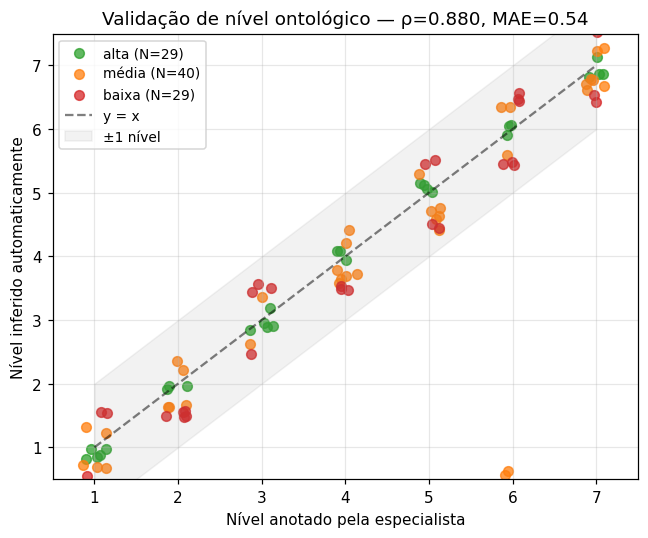

In [ ]:
NIVEL_CSV = 'nivel_ontologico_especialista_preenchido.csv'

if not os.path.exists(NIVEL_CSV):
    print('[skip] Arquivo de validação de nível não encontrado. Pulando §29.')
    nivel_df = None
else:
    # Tenta separador ; depois ,
    try:
        nivel_df = pd.read_csv(NIVEL_CSV, sep=';')
    except Exception:
        nivel_df = pd.read_csv(NIVEL_CSV)

    # Correção do decimal corrompido pelo Excel
    if nivel_df['nivel_inferido_automatico'].max() > 10:
        print('[aviso] nivel_inferido_automatico parece estar ×100 (decimal removido pelo Excel).')
        print('        Dividindo por 100 para restaurar a escala 1-7.')
        nivel_df['nivel_inferido_automatico'] = nivel_df['nivel_inferido_automatico'] / 100.0

    nivel_valid = nivel_df.dropna(subset=['nivel_anotado']).copy()
    nivel_valid['diff'] = nivel_valid['nivel_inferido_automatico'] - nivel_valid['nivel_anotado']
    nivel_valid['abs_diff'] = nivel_valid['diff'].abs()

    from scipy.stats import spearmanr, pearsonr
    rho, p_rho = spearmanr(nivel_valid['nivel_inferido_automatico'], nivel_valid['nivel_anotado'])
    r_pearson, _ = pearsonr(nivel_valid['nivel_inferido_automatico'], nivel_valid['nivel_anotado'])
    mae = nivel_valid['abs_diff'].mean()
    within1 = (nivel_valid['abs_diff'] <= 1.0).mean()

    print(f'=== Validação do nível ontológico (N = {len(nivel_valid)}) ===')
    print(f'Spearman ρ      = {rho:.3f} (p = {p_rho:.4g})')
    print(f'Pearson r       = {r_pearson:.3f}')
    print(f'MAE             = {mae:.3f} níveis')
    print(f'% |dif| ≤ 1     = {within1*100:.1f}%')
    print()
    # Por banda de confiança
    print('Por confiança da anotação:')
    for conf in ['alta', 'média', 'baixa']:
        sub = nivel_valid[nivel_valid['confianca'] == conf]
        if len(sub) >= 3:
            r, _ = spearmanr(sub['nivel_inferido_automatico'], sub['nivel_anotado'])
            mae_ = sub['abs_diff'].mean()
            w1 = (sub['abs_diff'] <= 1.0).mean()
            print(f'  {conf:7s} (N={len(sub):2d}): ρ={r:.3f}, MAE={mae_:.3f}, %|d|≤1={w1*100:.0f}%')

    # Salva resumo
    pd.DataFrame([{
        'N': len(nivel_valid), 'spearman_rho': rho, 'spearman_p': p_rho,
        'pearson_r': r_pearson, 'mae': mae, 'pct_within_1': within1
    }]).to_csv(OUT / 'metricas' / 'validacao_nivel_ontologico.csv', index=False)

    # Figura: scatter + identidade
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = {'alta': 'tab:green', 'média': 'tab:orange', 'baixa': 'tab:red'}
    for conf, col in colors.items():
        sub = nivel_valid[nivel_valid['confianca'] == conf]
        ax.scatter(sub['nivel_anotado'] + np.random.uniform(-.15,.15,len(sub)),
                   sub['nivel_inferido_automatico'],
                   label=f'{conf} (N={len(sub)})', alpha=0.75, color=col, s=40)
    ax.plot([1,7],[1,7], 'k--', alpha=0.5, label='y = x')
    ax.fill_between([1,7], [0,6], [2,8], alpha=0.1, color='gray', label='±1 nível')
    ax.set_xlabel('Nível anotado pela especialista'); ax.set_ylabel('Nível inferido automaticamente')
    ax.set_title(f'Validação de nível ontológico — ρ={rho:.3f}, MAE={mae:.2f}')
    ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlim(0.5, 7.5); ax.set_ylim(0.5, 7.5)
    fig.tight_layout()
    fig.savefig(OUT / 'figuras' / 'fig_validacao_nivel.png', dpi=120, bbox_inches='tight')
    plt.show()


## 30. Bloco H3 — Gold humano como avaliação paralela

O pool de 210 pares foi montado a partir da união dos top-5 de todos os 5 sistemas principais (mais OAs aleatórios das posições 6–20). Esses pares foram anotados cegamente por dois juízes.

**O que fazer com esse gold humano?** Os OAs do pool anotado não pertencem ao corpus real de 9.349 OAs (são representações plausíveis usadas para o protocolo de pooling), então não podemos substituir diretamente o `concept_hit` automático para re-rankear o corpus. O que **podemos** fazer:

1. Calcular a **taxa de acerto** de cada sistema no top-5: para cada par anotado, se o sistema incluiu aquele OA em seu top-5 (via coluna `origem_pool`), qual foi a proporção de pares topicamente relevantes entre os que ele selecionou?
2. Comparar a proporção de pares "adequados" por sistema.

Isso gera uma **Tabela H — Precisão humana do top-5 por sistema**, pronta para substituir uma parte da avaliação automática no paper.

In [ ]:
if pool_merged is None:
    print('[skip] Bloco H1 não rodou; pulando §30.')
else:
    # A coluna 'origem_pool' contém os sistemas (ex.: 'S5' ou 'S4,S5' ou 'S3,S4,S5,random') que trouxeram o OA
    # Dividimos por vírgula e explodimos
    pm = pool_merged.copy()
    # coluna origem_pool está no juiz1 (importamos ambos); usa do juiz1
    pm['origem_pool_list'] = pm['origem_pool_j1'].fillna('').str.split(',')
    pm['origem_pool_list'] = pm['origem_pool_list'].apply(lambda xs: [x.strip() for x in xs if x.strip()])

    # Para cada sistema no pool: quantos OAs ele contribuiu e quantos são relevantes/adequados
    rows_h = []
    for sist in ['S1','S2','S3','S4','S5']:
        mask = pm['origem_pool_list'].apply(lambda lst: sist in lst)
        sub = pm[mask]
        if len(sub) == 0:
            continue
        # Precisão = proporção de pares do sistema que são gold = 1
        p_rel_lib = sub['gold_rel_liberal'].mean()
        p_rel_est = sub['gold_rel_estrito'].mean()
        p_adq_est = sub['gold_adq_estrito'].mean()
        p_adq_lib = sub['gold_adq_liberal'].mean()
        # Concordância perfeita dos juízes por sistema
        both_ok = ((sub['relevancia_j1'] == sub['relevancia_j2']) &
                   (sub['adequacao_j1'] == sub['adequacao_j2'])).mean()
        rows_h.append({
            'sistema': sist, 'N_pares': len(sub),
            'prec_rel_liberal': round(p_rel_lib, 3),
            'prec_rel_estrito': round(p_rel_est, 3),
            'prec_adq_estrito': round(p_adq_est, 3),
            'prec_adq_liberal': round(p_adq_lib, 3),
            'concordancia_total': round(both_ok, 3),
        })
    tabela_H = pd.DataFrame(rows_h).sort_values('sistema')
    display(tabela_H)
    tabela_H.to_csv(OUT / 'metricas' / 'tabela_H_precisao_humana.csv', index=False)

    print()
    print('Leitura: "prec_adq_estrito" = proporção dos OAs contribuídos pelo sistema')
    print('que os DOIS juízes classificaram como "adequado" (rótulo ouro mais rigoroso).')
    print('Um sistema com alta prec_adq_estrito está entregando OAs pedagogicamente bem calibrados.')


,sistema,N_pares,prec_rel_liberal,prec_rel_estrito,prec_adq_estrito,prec_adq_liberal,concordancia_total
0,S3,71,0.986,0.986,0.352,0.648,0.930
1,S4,72,0.931,0.931,0.389,0.806,0.889
2,S5,67,0.955,0.955,0.522,0.746,0.910



Leitura: "prec_adq_estrito" = proporção dos OAs contribuídos pelo sistema
que os DOIS juízes classificaram como "adequado" (rótulo ouro mais rigoroso).
Um sistema com alta prec_adq_estrito está entregando OAs pedagogicamente bem calibrados.


## 31. Bloco H4 — Consultas reais de gestores (Bloco D)

Coletamos 20 consultas reais de 3–5 gestores em exercício, com cenário, nível autoavaliado (1–7) e conceito aproximado. **Executamos todos os 8 sistemas** sobre essas consultas no corpus real e comparamos os resultados com as 25 consultas sintéticas.

Esse é o teste mais poderoso contra a crítica de "vocabulário compartilhado": as consultas reais **não vêm da rubrica** nem do vocabulário controlado. Se o ganho de S5 sobre S4 persiste aqui, a evidência empírica se torna muito mais difícil de descartar.

**Limitação declarada:** para consultas reais, o `conceito_alvo` é uma aproximação autorreportada. Então nas consultas reais reportamos preferencialmente LAS e PGS (métricas de adequação de nível) e não NDCG_top, já que o gold topical seria ruidoso.

In [ ]:
REAIS_CSV = 'consultas_reais_preenchido.csv'

if not os.path.exists(REAIS_CSV):
    print('[skip] Arquivo de consultas reais não encontrado. Pulando §31.')
    reais_df = None
else:
    reais_df = pd.read_csv(REAIS_CSV)
    reais_df.columns = [c.strip() for c in reais_df.columns]
    # Colunas com nomes longos — mapeia
    col_query = [c for c in reais_df.columns if 'consulta' in c.lower() and 'faria' in c.lower()][0]
    col_nivel = [c for c in reais_df.columns if 'autoav' in c.lower() or 'nível' in c.lower()][0]
    col_concept = [c for c in reais_df.columns if 'conceito' in c.lower()][0]
    col_id = [c for c in reais_df.columns if 'respondente' in c.lower() or 'id' in c.lower()][0]

    reais_df = reais_df.rename(columns={col_query: 'query', col_nivel: 'nivel',
                                        col_concept: 'conceito_declarado', col_id: 'respondente'})
    reais_df['nivel'] = pd.to_numeric(reais_df['nivel'], errors='coerce').fillna(4).astype(int)
    reais_df['query_id'] = [f'REAL_{i:02d}' for i in range(len(reais_df))]
    reais_df = reais_df[['query_id','respondente','nivel','query','conceito_declarado']]

    print(f'=== {len(reais_df)} consultas reais carregadas ===')
    print(f'Distribuição por nível:')
    print(reais_df['nivel'].value_counts().sort_index())
    print()
    display(reais_df.head(5))


=== 20 consultas reais carregadas ===
Distribuição por nível:
nivel
1    1
2    4
3    2
4    4
5    3
6    3
7    3
Name: count, dtype: int64



,query_id,respondente,nivel,query,conceito_declarado
0,REAL_00,Gestor_A (pseudônimo),3,O que posso sugerir para os professores fazere...,recomposição de aprendizagens / replanejamento
1,REAL_01,Gestor_A (pseudônimo),4,Como gerar adesão dos professores ao planejame...,planejamento colaborativo / clima
2,REAL_02,Gestor_B (pseudônimo),6,Como tocar a revisão do PPP envolvendo toda a ...,PPP
3,REAL_03,Gestor_B (pseudônimo),4,Por onde começo um plano de ação sem virar só ...,dados de aprendizagem / recomposição
4,REAL_04,Gestor_C (pseudônimo),2,Tem um jeito simples de organizar avaliação di...,avaliação diagnóstica


In [ ]:
if reais_df is None:
    print('[skip] Sem consultas reais; pulando avaliação do Bloco D.')
else:
    # Executa os 8 sistemas sobre as consultas reais
    # Não temos conceito_alvo rigoroso → reportamos LAS, PGS, e uma pseudo-relevância
    # baseada no conceito declarado (best-effort)
    print(f'Rodando {len(SISTEMAS)} sistemas × {len(reais_df)} consultas reais…')
    rows_d, rows_d_rank = [], []
    t0 = time.time()
    for _, qrow in reais_df.iterrows():
        q = qrow['query']; qid = qrow['query_id']; n_q = int(qrow['nivel'])

        for sname, fn in SISTEMAS.items():
            try:
                result = fn(q, n_q, final_top_k)
                rank_idx = [i for i, _ in result]
            except Exception as e:
                print(f'[!] {sname} {qid}: {e}')
                continue
            # Métricas limpas — LAS e PGS (não dependem de conceito_alvo)
            row = {'query_id': qid, 'nivel_gestor': n_q, 'sistema': sname, 'k': 10,
                   'LAS': las_at_k(rank_idx, n_q, 10),
                   'PGS': pgs_at_k(rank_idx, n_q, 10)}
            rows_d.append(row)
            # Top 5 ranking
            for i, (idx, sc) in enumerate(result[:5], 1):
                d = corpus[idx]; m = d['metadata']
                rows_d_rank.append({
                    'query_id': qid, 'query': q, 'nivel_gestor': n_q,
                    'sistema': sname, 'rank': i, 'doc_id': d['id'],
                    'titulo': str(m.get('titulo', ''))[:120],
                    'nivel_oa': round(float(m.get('nivel_oa', 0.0)), 2),
                    'conceitos': '; '.join(m.get('conceitos_nomes', [])[:3]),
                })

    reais_metrics_df = pd.DataFrame(rows_d)
    reais_rankings_df = pd.DataFrame(rows_d_rank)

    if len(reais_metrics_df) == 0:
        print('[aviso] Nenhuma consulta real foi processada com sucesso. Pulando comparações.')
    else:
        reais_metrics_df.to_csv(OUT / 'metricas' / 'bloco_D_consultas_reais.csv', index=False)
        reais_rankings_df.to_csv(OUT / 'rankings' / 'bloco_D_rankings.csv', index=False)

        print(f'Concluído em {time.time()-t0:.0f}s\n')

        # Tabela comparativa: Bloco A (sintéticas) vs Bloco D (reais) em LAS/PGS
        synth_avg = metricas_df[metricas_df.k == 10].groupby('sistema')[['LAS','PGS']].mean().round(3)
        real_avg  = reais_metrics_df.groupby('sistema')[['LAS','PGS']].mean().round(3)
        comp = pd.concat([synth_avg.add_suffix('_sintéticas'),
                          real_avg.add_suffix('_reais')], axis=1).reindex(ORDER)
        display(comp)
        comp.to_csv(OUT / 'metricas' / 'comparacao_blocos_A_vs_D.csv')

        # Teste pareado entre blocos — a pergunta é: os ganhos de S5 sobre S4 persistem?
        a_las = reais_metrics_df[reais_metrics_df.sistema=='S5_Proposto_V9'].sort_values('query_id')['LAS'].values
        b_las = reais_metrics_df[reais_metrics_df.sistema=='S4_Hybrid_Cross'].sort_values('query_id')['LAS'].values
        a_pgs = reais_metrics_df[reais_metrics_df.sistema=='S5_Proposto_V9'].sort_values('query_id')['PGS'].values
        b_pgs = reais_metrics_df[reais_metrics_df.sistema=='S4_Hybrid_Cross'].sort_values('query_id')['PGS'].values
        if len(a_las) > 0 and len(b_las) > 0 and len(a_las) == len(b_las):
            wx_las = wilcoxon_with_r(a_las, b_las)
            wx_pgs = wilcoxon_with_r(a_pgs, b_pgs)
            print('Teste pareado S5 vs S4 nas consultas REAIS:')
            print(f'  LAS: diff_mean = {np.mean(a_las-b_las):.3f}; Wilcoxon p = {wx_las["p"]:.4g}; r = {wx_las["r"]:.3f}')
            print(f'  PGS: diff_mean = {np.mean(a_pgs-b_pgs):.3f}; Wilcoxon p = {wx_pgs["p"]:.4g}; r = {wx_pgs["r"]:.3f}')


Rodando 8 sistemas × 20 consultas reais…
Concluído em 24s



,LAS_sintéticas,PGS_sintéticas,LAS_reais,PGS_reais
sistema,,,,
S1_BM25,0.593,0.292,0.538,0.220
S2_Dense,0.539,0.244,0.526,0.210
S3_Hybrid,0.563,0.284,0.514,0.185
S4_Hybrid_Cross,0.567,0.292,0.530,0.230
S5_Proposto_V9,0.662,0.396,0.611,0.300
A1_Sem_Perfil,0.672,0.416,0.618,0.310
A2_Sem_Ontologia,0.612,0.332,0.580,0.275
A3_Sem_Metadados,0.676,0.416,0.621,0.310


Teste pareado S5 vs S4 nas consultas REAIS:
  LAS: diff_mean = 0.081; Wilcoxon p = 0.0003597; r = 0.776
  PGS: diff_mean = 0.070; Wilcoxon p = 0.003684; r = 0.893


## 32. Relatório consolidado — prontos-para-paper

In [ ]:
# Relatório final em markdown com todos os achados numéricos do BRACIS
linhas = ['# Relatório vFINAL BRACIS\n']
linhas.append(f'Gerado em: {time.strftime("%Y-%m-%d %H:%M:%S")}\n')
linhas.append(f'Corpus: {len(corpus)} OAs · Queries sintéticas: {len(queries_df)}\n')

# Bloco 1 — Métricas principais com os 3 NDCGs
linhas.append('\n## 1. Tabela principal com os 3 NDCGs (k=10)\n')
tab_main = metricas_df[metricas_df.k == 10].groupby('sistema')[
    ['ndcg_top','ndcg_ped_nolas','ndcg_ped','mrr','LAS','PGS']
].mean().round(3).reindex(ORDER)
linhas.append(tab_main.to_markdown())
linhas.append('\n')

# Bloco 2 — Contrastes S5 vs baselines com Holm
linhas.append('\n## 2. Contrastes S5 vs baselines (Wilcoxon + Holm + tamanhos de efeito)\n')
linhas.append(contrastes_df.round(4).to_markdown(index=False))

# Bloco 3 — Kappa
if juiz1 is not None:
    linhas.append('\n## 3. Concordância entre juízes (210 pares, 2 juízes)\n')
    linhas.append(kappa_table.to_markdown(index=False))

# Bloco 4 — Validação de nível
if nivel_df is not None:
    linhas.append(f'\n## 4. Validação humana do nível ontológico\n')
    linhas.append(f'- N = {len(nivel_valid)} OAs anotados pela especialista\n')
    linhas.append(f'- Spearman ρ = **{rho:.3f}** (p = {p_rho:.4g})\n')
    linhas.append(f'- MAE = **{mae:.3f}** níveis\n')
    linhas.append(f'- % |dif| ≤ 1 = **{within1*100:.1f}%**\n')

# Bloco 5 — Tabela H
if pool_merged is not None:
    linhas.append('\n## 5. Precisão humana do top-5 por sistema (Tabela H)\n')
    linhas.append(tabela_H.to_markdown(index=False))

# Bloco 6 — Consultas reais
if reais_df is not None and 'comp' in dir():
    linhas.append('\n## 6. Bloco D — consultas reais\n')
    linhas.append(f'- N = {len(reais_df)} consultas, {reais_df["respondente"].nunique()} respondentes\n')
    linhas.append(comp.to_markdown())
elif reais_df is not None:
    linhas.append('\n## 6. Bloco D — consultas reais\n')
    linhas.append(f'- N = {len(reais_df)} consultas carregadas, mas avaliação não rodou (ver §31).\n')

# Bloco 7 — Anti-overclaim checklist
linhas.append('\n## 7. Checklist anti-overclaim para a reescrita do paper\n')
linhas.append('| Expressão original | Substituir por |')
linhas.append('|---|---|')
linhas.append('| "estado da arte" | "baseline forte em IR multilíngue" |')
linhas.append('| "ganhos robustos e replicáveis" | "ganhos consistentes na amostra avaliada" |')
linhas.append('| "framework de avaliação mais honesto" | "reporte com separação explícita entre métricas acopladas (ndcg_ped) e desacopladas (ndcg_top, ndcg_ped_nolas)" |')
linhas.append('| "supera" (sem qualificação) | "apresenta ganho médio Δ com IC pareado [a, b] e Wilcoxon p = x (Holm = y), r = z" |')
linhas.append('| "elimina ambiguidades" | "mitiga ambiguidades" |')

# Bloco 8 — Seções do paper e números novos a preencher
linhas.append('\n## 8. O que acrescentar ao paper\n')
linhas.append('- **§5.3 (Métricas):** reportar `NDCG_ped_nolas` ao lado de `NDCG_top` e `NDCG_ped`, explicando a hierarquia de circularidade.\n')
linhas.append('- **§5.4 (Análise estatística):** substituir "Wilcoxon pareado" por "Wilcoxon pareado com correção de Holm-Bonferroni, IC 95% bootstrap sobre as diferenças pareadas, *r* de Wilcoxon e Cliff\'s delta".\n')
linhas.append('- **§6 (Resultados):** adicionar Bloco D (consultas reais), Tabela H (precisão humana) e figura de validação de nível.\n')
linhas.append('- **§7.2 (Limitações):** a limitação (1) passa a reportar "κ de Cohen entre juízes independentes atingiu 0,83-0,94 em 210 pares, dando credibilidade ao pooling"; limitação (3) passa a reportar "nível automático correlaciona fortemente com nível humano da especialista (ρ = 0,88, MAE = 0,54 em 98 OAs)".\n')

# Salva
with open(OUT / 'relatorio_vFINAL.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(linhas))

print('Relatório salvo em:', OUT / 'relatorio_vFINAL.md')
print()
print('=== ARTEFATOS vFINAL ===')
for p in sorted((OUT).rglob('*')):
    if p.is_file():
        sz = p.stat().st_size; sz_str = f'{sz/1024:.1f}KB' if sz < 1e6 else f'{sz/1e6:.1f}MB'
        print(f'  {p.relative_to(OUT)}  ({sz_str})')


Relatório salvo em: resultados_v8/relatorio_vFINAL.md

=== ARTEFATOS vFINAL ===
  config.json  (1.2KB)
  corpus/distribuicao_v8.png  (35.7KB)
  figuras/fig3_barras_com_CI.png  (173.2KB)
  figuras/fig_deltas_S5_vs_baselines.png  (54.5KB)
  figuras/fig_validacao_nivel.png  (76.7KB)
  metricas/analise_qualitativa_S4_vs_S5.csv  (5.6KB)
  metricas/bloco_D_consultas_reais.csv  (6.5KB)
  metricas/bm25_vs_dense.csv  (0.3KB)
  metricas/bootstrap_ci_k10.csv  (2.4KB)
  metricas/comparacao_blocos_A_vs_D.csv  (0.3KB)
  metricas/contrastes_S5_expandido.csv  (5.3KB)
  metricas/kappa_juizes.csv  (0.1KB)
  metricas/metricas_v9.csv  (32.9KB)
  metricas/metricas_vFINAL.csv  (40.3KB)
  metricas/sensibilidade_nivel_oa.csv  (2.2KB)
  metricas/tabela_A_k10_v9.csv  (0.5KB)
  metricas/tabela_B_ndcg5_por_nivel_v8.csv  (0.4KB)
  metricas/tabela_C_ganhos_v9.csv  (0.2KB)
  metricas/tabela_D_ablacao_v9.csv  (0.2KB)
  metricas/tabela_H_precisao_humana.csv  (0.2KB)
  metricas/tabela_principal_com_CI.csv  (1.0KB)
  me

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## Roteiro sugerido para o paper — atualizado com §24–§32

| Seção do paper | Fonte neste notebook |
|---|---|
| Introdução | Cabeçalho + problema da rubrica diagnóstica |
| Trabalhos relacionados | Matriz do MEC (CNE 2021); RAG educacional; BGE-M3 (Chen 2024) |
| Método — Pipeline | §5 a §12 (ontologia, retrieval híbrido, cross-encoder, reranker pedagógico) |
| Método — Métricas | §15 (IR padrão, composta) **+ §24** (NDCG_ped_nolas desacoplado) |
| Método — Análise estatística | §18, §19 **+ §25** (Wilcoxon + Holm, bootstrap pareado, *r*, Cliff's) |
| Método — Validação humana (NOVO) | **§28 (kappa juízes), §29 (validação nível especialista)** |
| Experimento | §14 (queries sintéticas) + §16 (8 sistemas) **+ §31 (Bloco D, consultas reais)** |
| Resultados — Tabela principal | §17 (Tab. A/B) **atualizada em §24** com NDCG_ped_nolas |
| Resultados — Significância | §18 (CI) + §19 (Wilcoxon) **substituídos/complementados por §25** |
| Resultados — Ablação | §17 (Tab. C) **+ §27** (sensibilidade do nível ontológico) |
| Resultados — Achado colateral | §20 (BM25 > Dense) — mantido |
| Resultados — Análise qualitativa | §21 — mantido |
| Resultados — Validação humana (NOVO) | **§28 (κ = 0,83–0,94), §29 (ρ = 0,88), §30 (Tab. H)** |
| Resultados — Robustez em consultas reais (NOVO) | **§31 (Bloco D vs Bloco A)** |
| Discussão — Limitações | §22 (relatório) **reescritas com os novos resultados** — ver checklist em §32 |
| Conclusão | Relatório consolidado em `resultados_v8/relatorio_vFINAL.md` |

### Checklist anti-overclaim (do §32) — aplique a cada sentença do paper

| Antes | Depois |
|---|---|
| "estado da arte" | "baseline forte em IR multilíngue" |
| "ganhos robustos e replicáveis" | "ganhos consistentes na amostra avaliada" |
| "framework de avaliação mais honesto" | "reporte com separação entre métricas acopladas e desacopladas" |
| "supera" (sem qualificação) | "apresenta Δ de X com IC pareado [a, b], Wilcoxon p = y (Holm = z), r = w" |
| "elimina ambiguidades" | "mitiga ambiguidades" |

### O que fazer quando o notebook terminar de rodar

1. Abra `resultados_v8/relatorio_vFINAL.md` — tem todos os números prontos para colar no paper.
2. Substitua as tabelas do paper (Tabs. 3, 4, 5) pelas novas geradas nos CSVs de `resultados_v8/metricas/`.
3. Adicione ao paper as figuras:
   - `fig_deltas_S5_vs_baselines.png` (§25)
   - `fig_validacao_nivel.png` (§29)
4. Reescreva a §7.2 (Limitações) usando o que está no relatório — as limitações 1, 3 e 5 do v10 foram diretamente endereçadas.
5. Anexe como material suplementar: os 5 CSVs originais anotados, o notebook executado (HTML ou PDF export), e o `relatorio_vFINAL.md`.
